In [127]:
import pandas as pd
import pykalman as pk
import numpy as np
from scipy.linalg import toeplitz

In [128]:
data = pd.read_csv("src/data/week1.csv")

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
data["dx"] = np.cos(data["dir"])*data["s"]
data["dy"] = np.sin(data["dir"])*data["s"]
data["d2y"] = np.sin(data["dir"])*data["a"]
data["d2x"] = np.cos(data["dir"]) * data["a"]

In [ ]:
delta = .1
column = np.array([1,0,0])
first_line = np.array([1, delta, delta**2 * .5])
transition_matrices = toeplitz(column, first_line)

In [ ]:
transition_matrices

array([[1.   , 0.1  , 0.005],
       [0.   , 1.   , 0.1  ],
       [0.   , 0.   , 1.   ]])

In [ ]:
observation_matrices = np.eye(3)

In [ ]:
observation_covariance = np.eye(3)
Q = np.array([[(delta**3)/6, .5 * delta**2, delta]])
transition_covariance = Q.T.dot(Q)

In [ ]:
kf = pk.KalmanFilter(transition_covariance=transition_covariance, transition_matrices=transition_matrices, observation_covariance=observation_covariance,
                     observation_matrices=observation_matrices)

In [ ]:
def smooth_data_x(data, transition_covariance, observation_covariance):
    obs = data.sort_values(by ="frameId", ascending=True)[["x","dx","d2x"]].to_numpy()
    kf = pk.KalmanFilter(transition_covariance=transition_covariance, transition_matrices=transition_matrices, observation_covariance=observation_covariance,
                     observation_matrices=observation_matrices, initial_state_covariance = np.eye(3)*.001, initial_state_mean = obs[0])
    return kf.smooth(obs)[0]

In [ ]:
def smooth_data_y(data, transition_covariance, observation_covariance):
    obs = data.sort_values(by ="frameId", ascending=True)[["y","dy","d2y"]].to_numpy()
    kf = pk.KalmanFilter(transition_covariance=transition_covariance, transition_matrices=transition_matrices, observation_covariance=observation_covariance,
                     observation_matrices=observation_matrices, initial_state_covariance = np.eye(3)*.001, initial_state_mean = obs[0])
    return kf.smooth(obs)[0]

In [ ]:

smoothed_data_x = data.groupby(["nflId","gameId","playId"], group_keys=True).apply(lambda x: smooth_data_x(x, transition_covariance, observation_covariance)).reset_index().explode(0)


In [ ]:

smoothed_data_y = data.groupby(["nflId","gameId","playId"], group_keys=True).apply(lambda x: smooth_data_y(x, transition_covariance, observation_covariance)).reset_index().explode(0)


In [ ]:
smoothed_data_x.rename(columns = {0:"smooth"}, inplace = True)
smoothed_data_y.rename(columns = {0:"smooth"}, inplace = True)

In [ ]:
smoothed_data_x

,nflId,gameId,playId,smooth
0,25511.0,2021090900,97,"[37.74501792984591, -0.31747103912813657, -0.3..."
0,25511.0,2021090900,97,"[37.7115410444637, -0.3539361845641177, -0.420..."
0,25511.0,2021090900,97,"[37.67389814937338, -0.40037763679122906, -0.5..."
0,25511.0,2021090900,97,"[37.63120977865547, -0.45449124251787465, -0.5..."
0,25511.0,2021090900,97,"[37.5828118695638, -0.5142457874246512, -0.620..."
...,...,...,...,...
25849,53957.0,2021091204,3597,"[64.04844330934846, -1.263680990186958, -0.175..."
25849,53957.0,2021091204,3597,"[63.921305888907675, -1.277986716509224, -0.11..."
25849,53957.0,2021091204,3597,"[63.79300861372942, -1.2874130123469893, -0.07..."
25849,53957.0,2021091204,3597,"[63.66388418785233, -1.2950122657630518, -0.07..."


In [ ]:
smoothed_x_columns = smoothed_data_x["smooth"].apply(pd.Series)
smoothed_y_columns = smoothed_data_y["smooth"].apply(pd.Series)

In [ ]:
smoothed_x_columns.rename(columns = {0:"x_smooth",1:"dx_smooth",2:"d2x_smooth"},inplace=True)
smoothed_y_columns.rename(columns = {0:"y_smooth",1:"dy_smooth",2:"d2y_smooth"},inplace=True)

In [ ]:
smoothed_y_columns

,y,dy,d2y
0,24.215529,-0.056962,-0.055653
0,24.209465,-0.065208,-0.109267
0,24.202322,-0.078404,-0.154655
0,24.193644,-0.095804,-0.193350
0,24.183038,-0.116922,-0.229007
...,...,...,...
25849,22.871363,1.357084,0.532302
25849,23.009769,1.411404,0.554106
25849,23.153685,1.466945,0.556717
25849,23.303235,1.524791,0.600203


In [ ]:
smoothed_data = pd.concat([smoothed_x_columns,smoothed_y_columns], axis = 1)

In [ ]:
# smoothed_data = smoothed_data.join(smoothed_data_x[["playId","gameId","nflId"]])

In [ ]:
smoothed_data = pd.concat([smoothed_data, smoothed_data_x[["playId","nflId","gameId"]]], axis = 1)

In [ ]:
smoothed_data["frameId"] = smoothed_data.groupby(["nflId","playId","gameId"]).cumcount() + 1

In [ ]:
smoothed_data.merge(data)

,x_smooth,dx_smooth,d2x_smooth,y_smooth,dy_smooth,d2y_smooth,playId,nflId,gameId,frameId,...,s,a,dis,o,dir,event,dx,dy,d2y,d2x
0,37.745018,-0.317471,-0.308566,24.215529,-0.056962,-0.055653,97,25511.0,2021090900,1,...,0.29,0.30,0.03,165.16,84.99,None,-0.285966,-0.048205,-0.049867,-0.295826
1,37.711541,-0.353936,-0.420737,24.209465,-0.065208,-0.109267,97,25511.0,2021090900,2,...,0.23,0.11,0.02,164.33,92.87,None,0.044119,-0.225729,-0.107957,0.021100
2,37.673898,-0.400378,-0.508092,24.202322,-0.078404,-0.154655,97,25511.0,2021090900,3,...,0.16,0.10,0.01,160.24,68.55,None,0.135131,-0.085672,-0.053545,0.084457
3,37.631210,-0.454491,-0.574180,24.193644,-0.095804,-0.193350,97,25511.0,2021090900,4,...,0.15,0.24,0.06,152.13,296.85,None,0.004575,0.149930,0.239888,0.007320
4,37.582812,-0.514246,-0.620911,24.183038,-0.116922,-0.229007,97,25511.0,2021090900,5,...,0.25,0.18,0.04,148.33,287.55,None,0.023533,-0.248890,-0.179201,0.016944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1069503,64.048443,-1.263681,-0.175478,22.871363,1.357084,0.532302,3597,53957.0,2021091204,23,...,6.46,1.79,0.66,319.24,310.75,None,-6.229953,1.708591,0.473433,-1.726256
1069504,63.921306,-1.277987,-0.110636,23.009769,1.411404,0.554106,3597,53957.0,2021091204,24,...,6.01,3.47,0.62,300.62,308.69,None,4.126790,4.369176,2.522636,2.382689
1069505,63.793009,-1.287413,-0.077890,23.153685,1.466945,0.556717,3597,53957.0,2021091204,25,...,5.54,4.28,0.57,277.78,306.91,None,3.149649,-4.557555,-3.521000,2.433303
1069506,63.663884,-1.295012,-0.074095,23.303235,1.524791,0.600203,3597,53957.0,2021091204,26,...,5.07,5.30,0.53,199.67,302.04,None,4.571631,2.192051,2.291493,4.779023


In [ ]:
import stan
import pandas as pd

In [ ]:
design_matrix = pd.read_csv("src/blocker_rusher_design_matrix.csv").to_numpy()[:, 1:]
feature_data = pd.read_csv("src/strain_design_data.csv")

In [ ]:
design_matrix.columns.values

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
target = feature_data["y_jt"]
strain_velo = .5 * (feature_data["strain_rate"])**2

n_blockers = design_matrix.shape[1]
n_rushers = len(set(feature_data["nflId_pr"]))
N = design_matrix.shape[0]
rusher_identifier = feature_data["nflId_pr"].astype("category").cat.codes + 1

In [ ]:
stan_data = {"velocity" :strain_velo.values, "N" : N, "rusher_identifier" : rusher_identifier.values,
                  "X_blockers" : design_matrix, "acceleration" : target.values, 
                  "N_blockers" : n_blockers, "N_rushers" : n_rushers}

In [ ]:
stan_data

{'velocity': array([0.00102302, 0.00043923, 0.0011777 , ..., 0.00019646, 0.00015708,
        0.00013761]),
 'N': 1150273,
 'rusher_identifier': array([  1,   1,   1, ..., 698, 698, 698], dtype=int16),
 'X_blockers': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 'acceleration': array([ 0.02417641,  0.05928988,  0.03618987, ..., -0.01980282,
        -0.01794567, -0.01288413]),
 'N_blockers': 534,
 'N_rushers': 698}

In [ ]:
with open("src/strain.stan") as f:
    stan_code = f.read()
    f.close()

In [ ]:
posterior = stan.build(stan_code, data=stan_data, random_seed=1)

In [244]:
import arviz as az
import pandas as pd

# feature_data = pd.read_csv("src/strain_design_data.csv")

idata = az.from_netcdf("src/pymc_posterior_sample_frame_level_strain.nc")

In [367]:
idata



Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

/Users/abhijitbrahme/Library/Caches/pypoetry/virtualenvs/matchup-identifier-NB4Vme2p-py3.9/lib/python3.9/site-packages/arviz/plots/plot_utils.py:271: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (402) in plot_ess, generating only 40 plots
  warnings.warn(


array([[<AxesSubplot: title={'center': 'beta_blocker\n0'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_blocker\n1'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_blocker\n2'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_blocker\n3'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
       [<AxesSubplot: title={'center': 'beta_blocker\n4'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_blocker\n5'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_blocker\n6'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_blocker\n7'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
       [<AxesSubplot: title={'center': 'beta_blocker\n8'}, xlabel='Quantile', ylabel='ESS for 

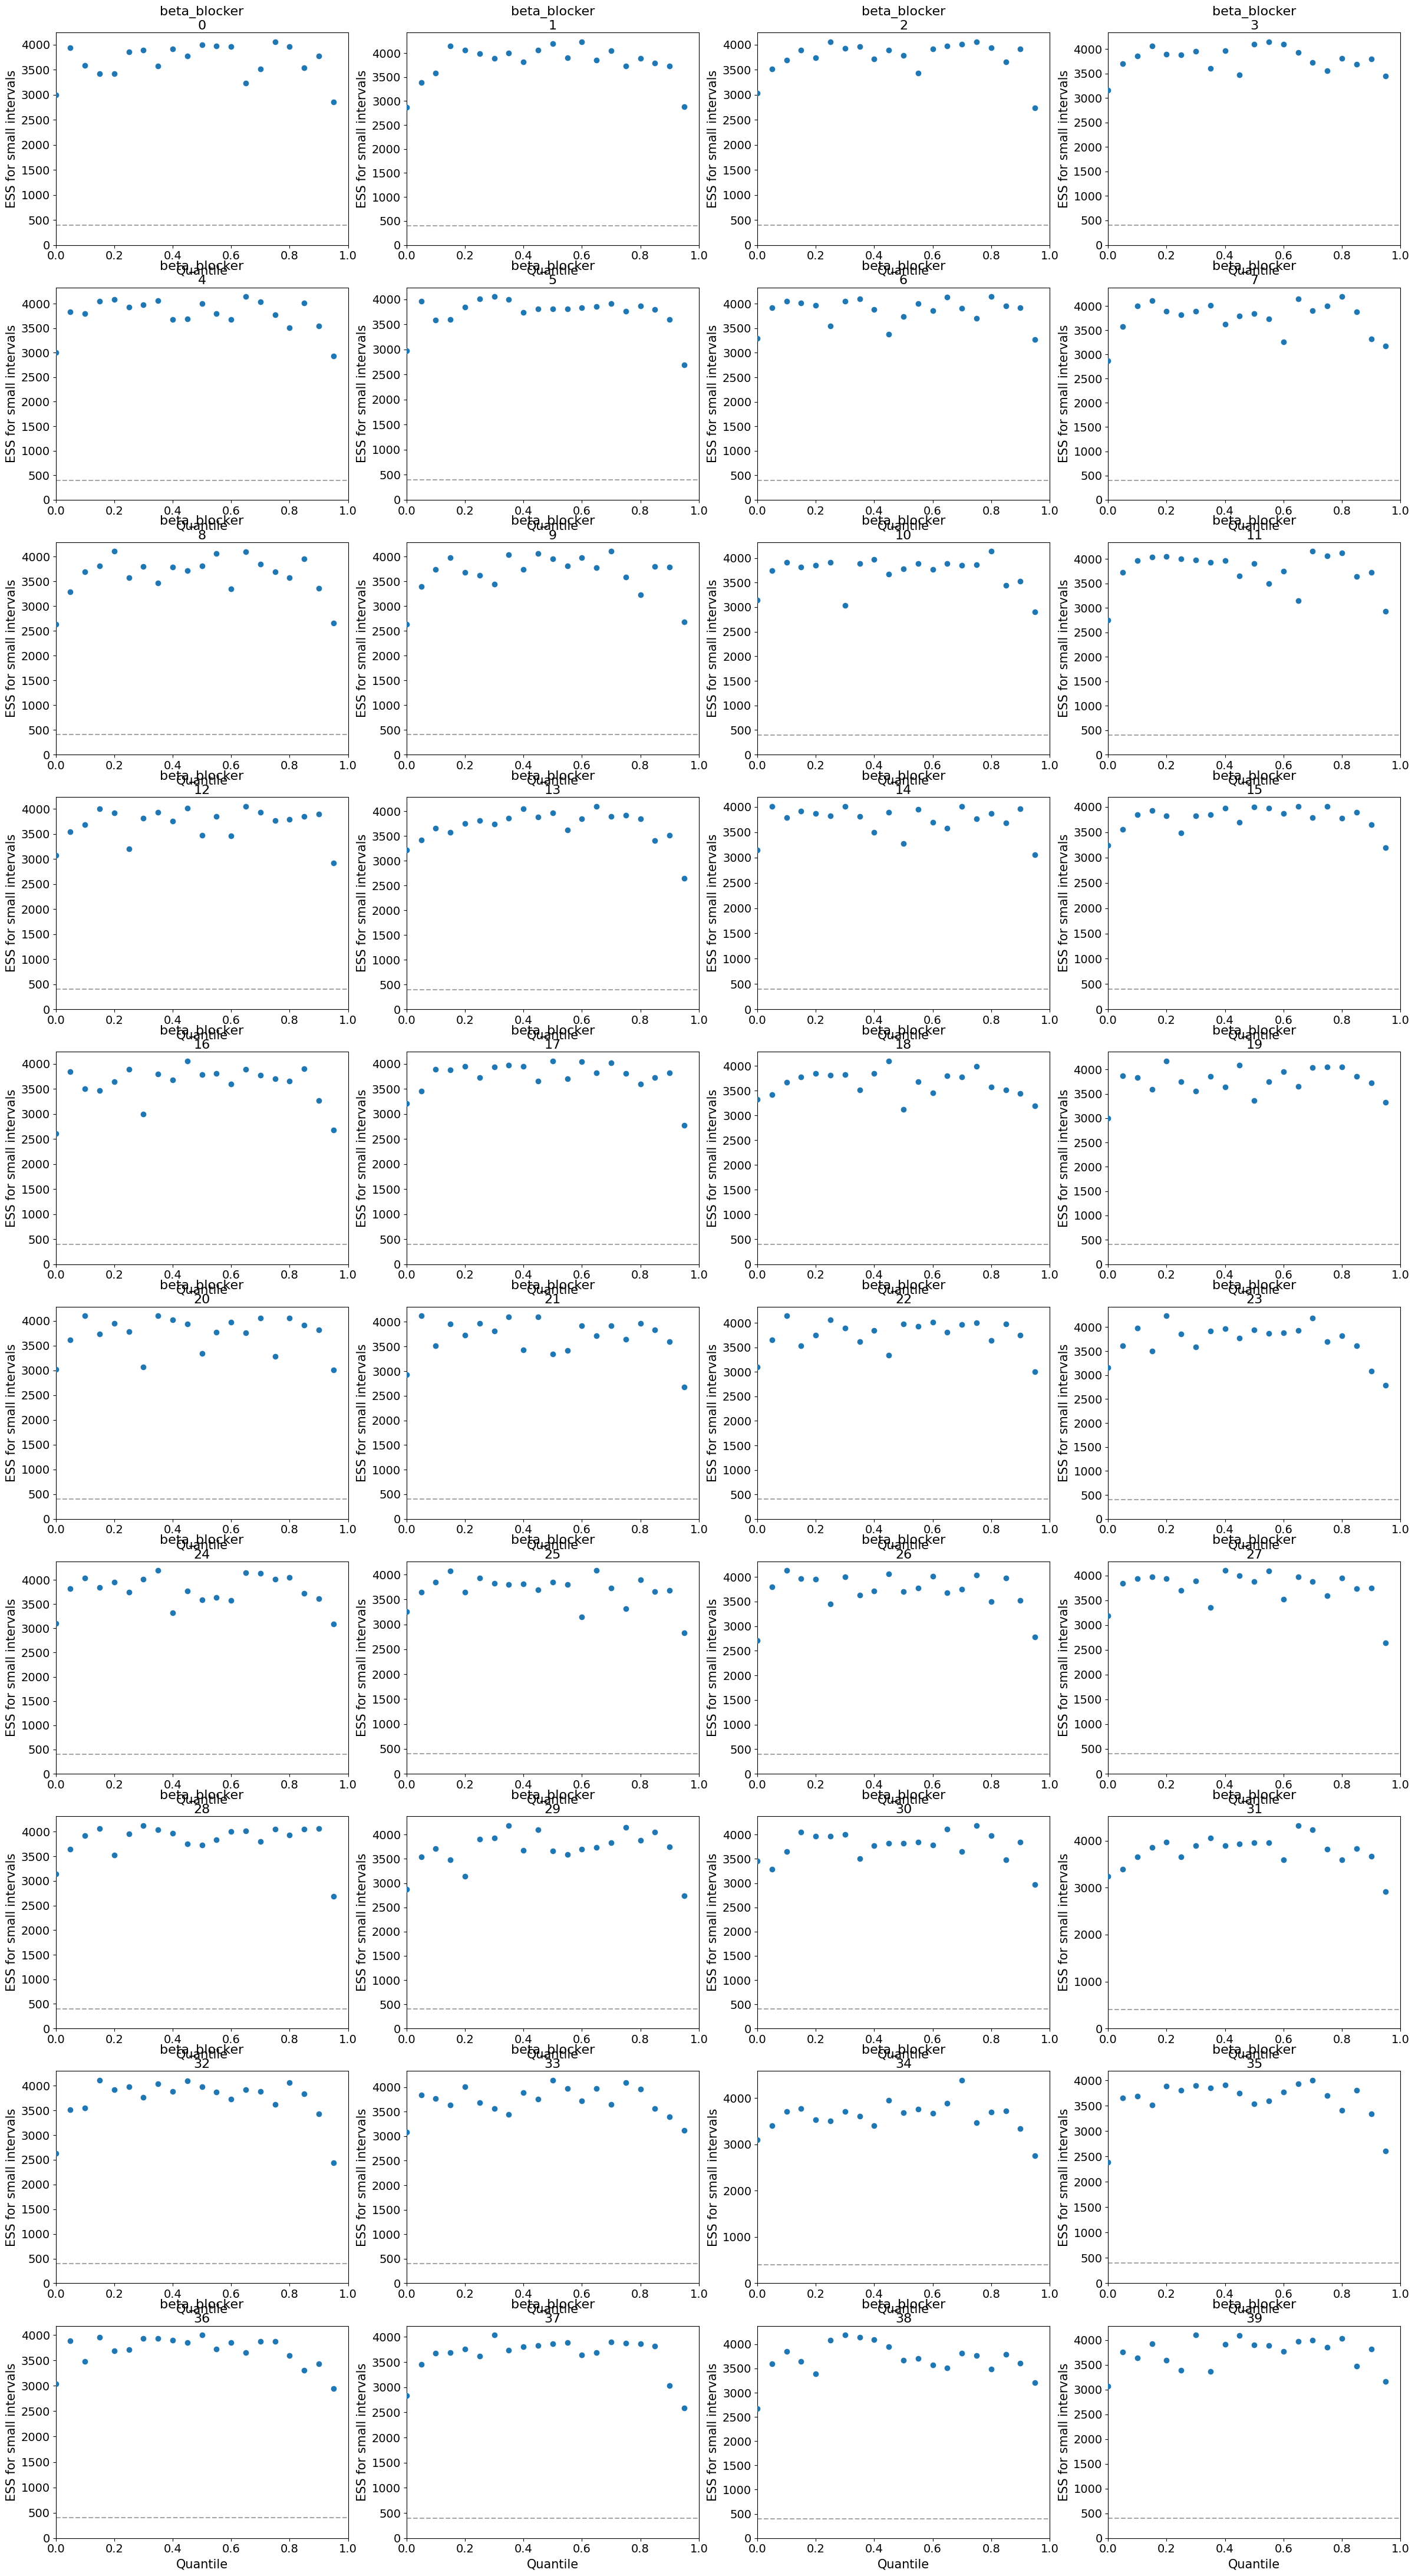

In [368]:
az.plot_ess(idata.posterior.beta_blocker)

/Users/abhijitbrahme/Library/Caches/pypoetry/virtualenvs/matchup-identifier-NB4Vme2p-py3.9/lib/python3.9/site-packages/arviz/plots/plot_utils.py:271: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (696) in plot_ess, generating only 40 plots
  warnings.warn(


array([[<AxesSubplot: title={'center': 'beta_rusher\n0'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_rusher\n1'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_rusher\n2'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_rusher\n3'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
       [<AxesSubplot: title={'center': 'beta_rusher\n4'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_rusher\n5'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_rusher\n6'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_rusher\n7'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
       [<AxesSubplot: title={'center': 'beta_rusher\n8'}, xlabel='Quantile', ylabel='ESS for small int

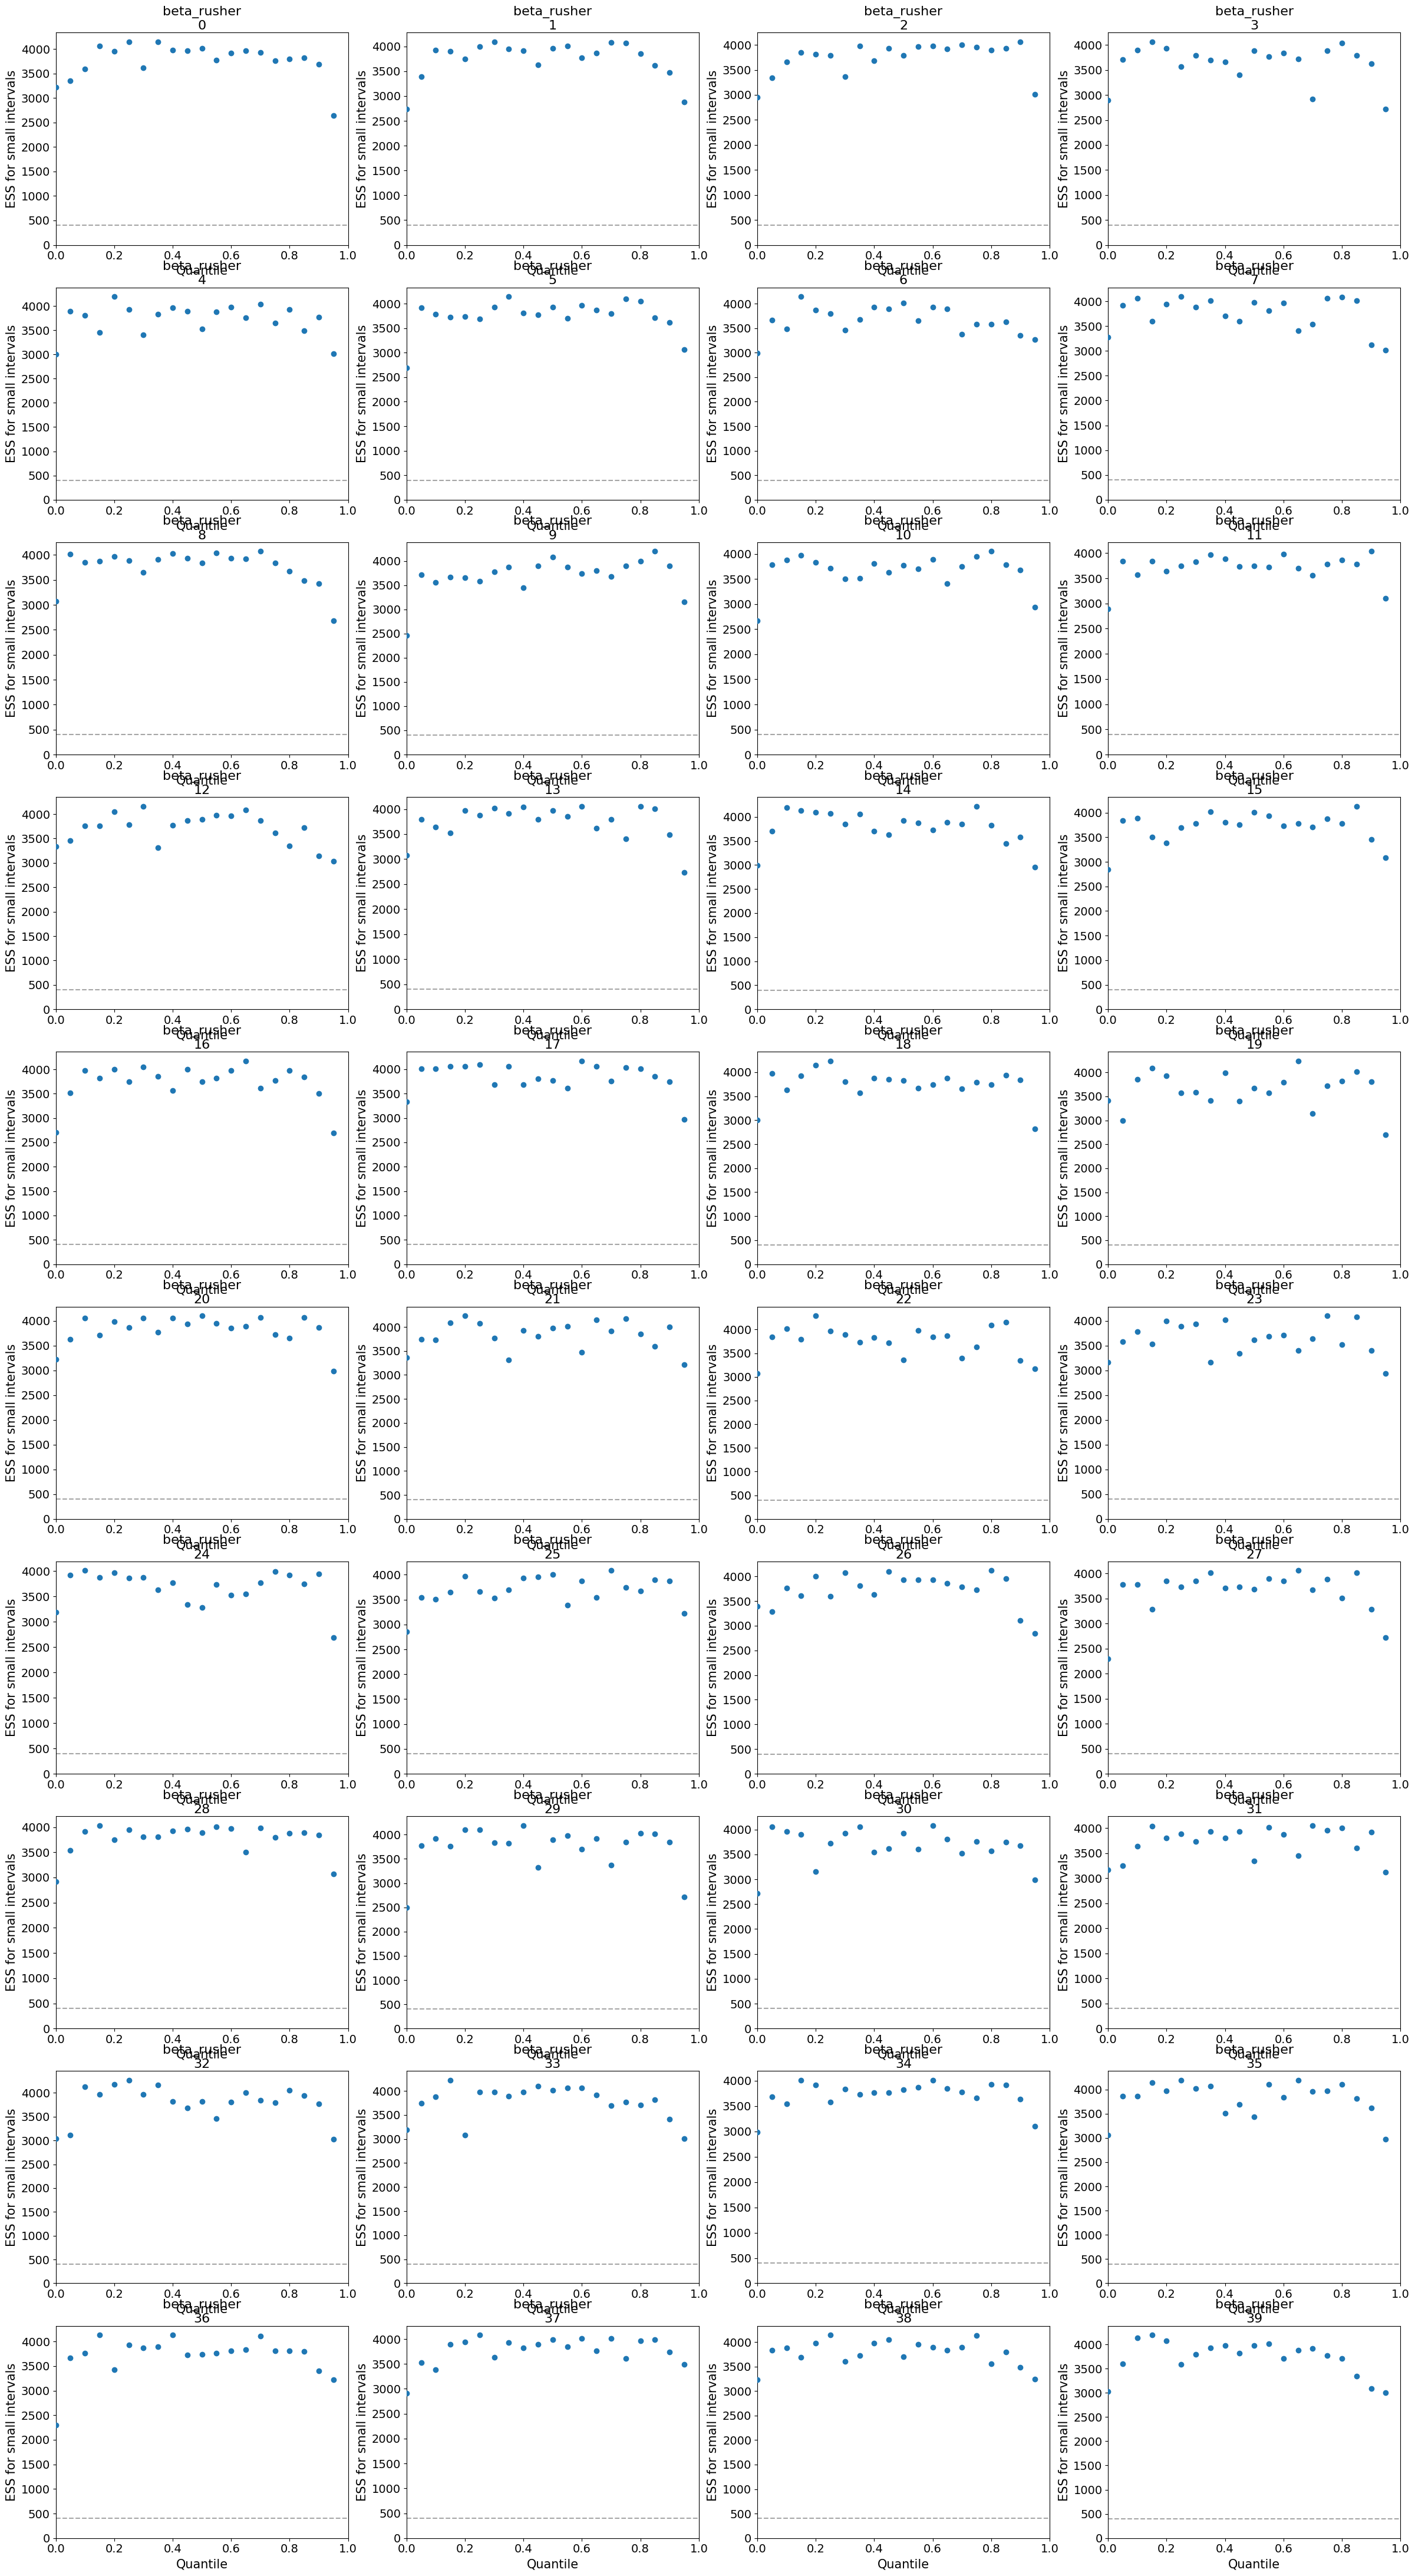

In [369]:
az.plot_ess(idata.posterior.beta_rusher)

array([[<AxesSubplot: title={'center': 'beta_offense\n0'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_offense\n1'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_offense\n2'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_offense\n3'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
       [<AxesSubplot: title={'center': 'beta_offense\n4'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_offense\n5'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_offense\n6'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_offense\n7'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
       [<AxesSubplot: title={'center': 'beta_offense\n8'}, xlabel='Quantile', ylabel='ESS for 

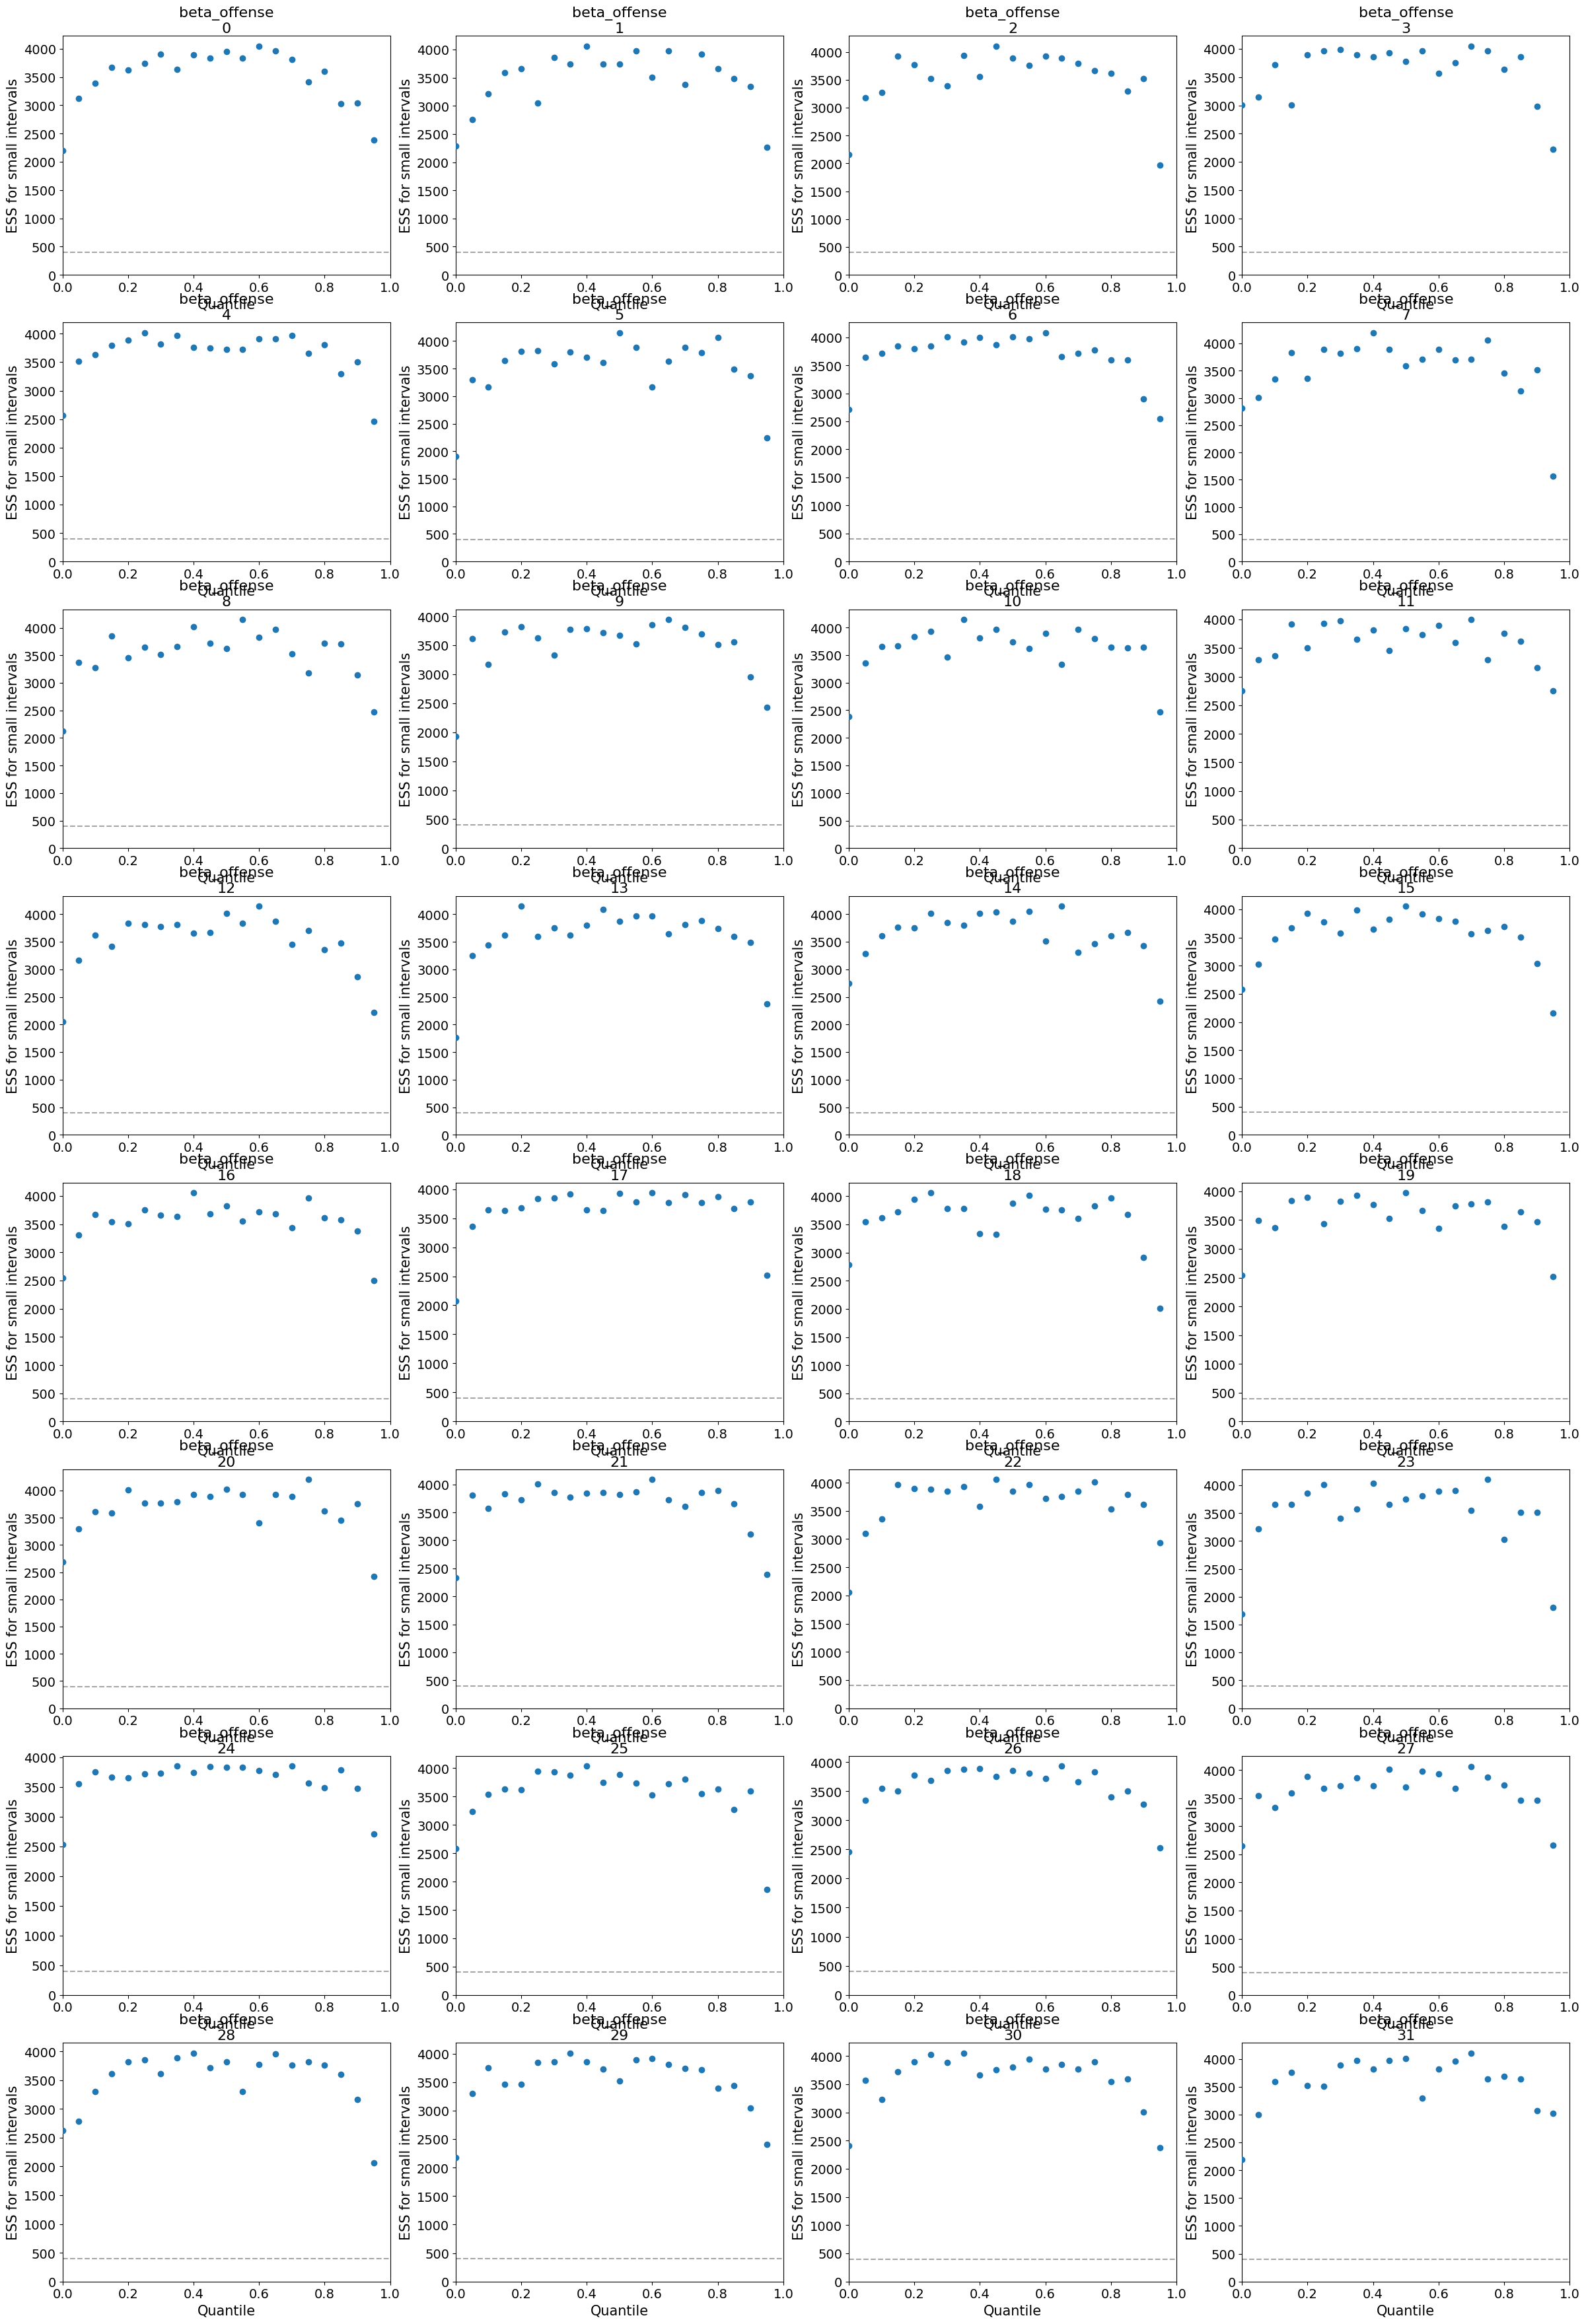

In [370]:
az.plot_ess(idata.posterior.beta_offense)

<AxesSubplot: title={'center': 'sigma'}, xlabel='Quantile', ylabel='ESS for small intervals'>

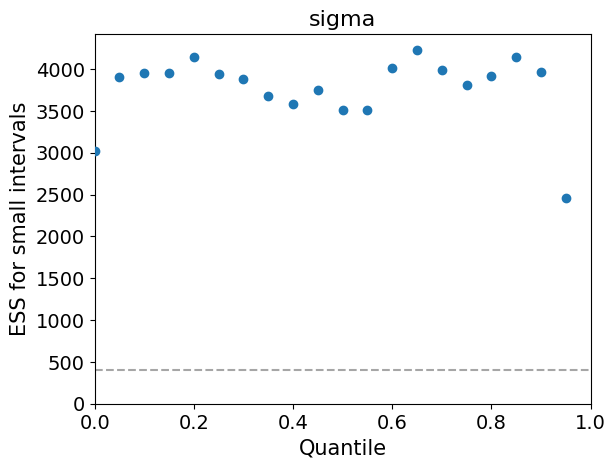

In [371]:
az.plot_ess(idata.posterior.sigma)

<AxesSubplot: title={'center': 'sigma_rusher'}, xlabel='Quantile', ylabel='ESS for small intervals'>

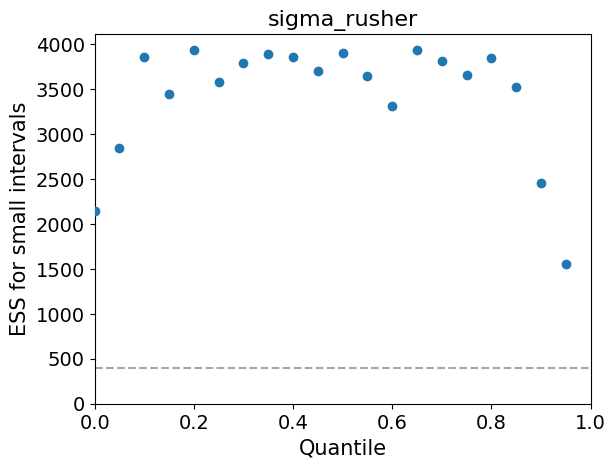

In [372]:
az.plot_ess(idata.posterior.sigma_rusher)

<AxesSubplot: title={'center': 'sigma_blocker'}, xlabel='Quantile', ylabel='ESS for small intervals'>

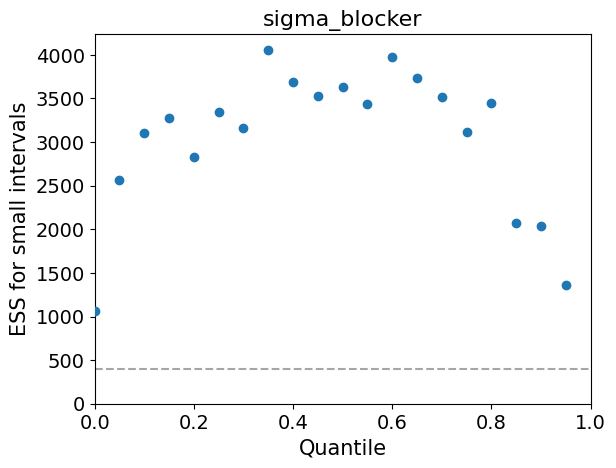

In [373]:
az.plot_ess(idata.posterior.sigma_blocker)

In [4]:
az.summary(idata.posterior.sigma)

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.015,0.0,0.015,0.016,0.0,0.0,5000.0,4893.0,NaN


In [5]:
az.summary(idata.posterior.sigma_rusher)

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_rusher,0.656,0.077,0.508,0.792,0.001,0.001,4847.0,5025.0,NaN


In [6]:
az.summary(idata.posterior.sigma_blocker)

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_blocker,0.623,0.085,0.464,0.779,0.001,0.001,4919.0,4983.0,NaN


In [7]:
az.summary(idata.posterior.sigma_offense)

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_offense,0.793,0.454,0.17,1.564,0.007,0.005,4854.0,4661.0,NaN


In [8]:
az.summary(idata.posterior.sigma_defense)

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_defense,0.562,0.361,0.1,1.201,0.005,0.004,4820.0,4824.0,NaN


In [9]:
az.summary(idata.posterior.beta_blocker)

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_blocker[0],0.255,0.008,0.240,0.269,0.000,0.000,4965.0,5012.0,NaN
beta_blocker[1],-0.011,0.685,-1.254,1.335,0.010,0.007,5082.0,4826.0,NaN
beta_blocker[2],-0.140,0.005,-0.150,-0.130,0.000,0.000,4495.0,4820.0,NaN
beta_blocker[3],-0.740,0.007,-0.755,-0.727,0.000,0.000,4226.0,4393.0,NaN
beta_blocker[4],-0.026,0.450,-0.892,0.790,0.006,0.005,4873.0,4861.0,NaN
...,...,...,...,...,...,...,...,...,...
beta_blocker[529],-0.130,0.026,-0.176,-0.080,0.000,0.000,4903.0,4612.0,NaN
beta_blocker[530],0.008,0.688,-1.328,1.231,0.010,0.007,4911.0,4776.0,NaN
beta_blocker[531],0.087,0.007,0.074,0.100,0.000,0.000,4758.0,4364.0,NaN
beta_blocker[532],0.009,0.693,-1.275,1.324,0.010,0.007,5175.0,4895.0,NaN


In [10]:
az.summary(idata.posterior.beta_rusher)

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_rusher[0],0.497,0.007,0.484,0.509,0.000,0.000,4784.0,4802.0,NaN
beta_rusher[1],0.082,0.006,0.069,0.093,0.000,0.000,4783.0,4678.0,NaN
beta_rusher[2],0.002,0.688,-1.286,1.288,0.010,0.007,5052.0,4856.0,NaN
beta_rusher[3],0.018,0.682,-1.260,1.244,0.010,0.007,5144.0,4712.0,NaN
beta_rusher[4],0.387,0.005,0.378,0.395,0.000,0.000,4904.0,4474.0,NaN
...,...,...,...,...,...,...,...,...,...
beta_rusher[691],0.003,0.687,-1.333,1.214,0.010,0.007,5004.0,4938.0,NaN
beta_rusher[692],-0.015,0.693,-1.309,1.282,0.010,0.007,5137.0,5116.0,NaN
beta_rusher[693],0.005,0.688,-1.307,1.298,0.010,0.007,5216.0,4736.0,NaN
beta_rusher[694],0.014,0.703,-1.318,1.300,0.011,0.008,4191.0,4662.0,NaN


In [11]:
az.summary(idata.posterior.beta_offense)

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_offense[0],0.110,0.004,0.102,0.118,0.0,0.0,4798.0,4860.0,NaN
beta_offense[1],0.015,0.005,0.006,0.024,0.0,0.0,4688.0,4938.0,NaN
beta_offense[2],-0.066,0.004,-0.074,-0.058,0.0,0.0,4966.0,4137.0,NaN
beta_offense[3],-0.013,0.004,-0.022,-0.005,0.0,0.0,4698.0,5038.0,NaN
beta_offense[4],0.170,0.004,0.162,0.177,0.0,0.0,5005.0,4830.0,NaN
beta_offense[5],-0.146,0.004,-0.154,-0.139,0.0,0.0,4830.0,4858.0,NaN
beta_offense[6],-0.115,0.004,-0.123,-0.107,0.0,0.0,4914.0,4706.0,NaN
beta_offense[7],-0.155,0.004,-0.164,-0.147,0.0,0.0,5067.0,4858.0,NaN
beta_offense[8],-0.998,0.004,-1.006,-0.990,0.0,0.0,4928.0,4409.0,NaN
beta_offense[9],-0.010,0.004,-0.018,-0.002,0.0,0.0,5115.0,4685.0,NaN


In [12]:
az.summary(idata.posterior.beta_defense)

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_defense[0],0.066,0.005,0.057,0.075,0.0,0.0,4881.0,4672.0,NaN
beta_defense[1],-0.036,0.004,-0.043,-0.029,0.0,0.0,4806.0,4779.0,NaN
beta_defense[2],-0.072,0.004,-0.081,-0.065,0.0,0.0,5097.0,4215.0,NaN
beta_defense[3],0.004,0.004,-0.004,0.011,0.0,0.0,5009.0,4440.0,NaN
beta_defense[4],-0.445,0.004,-0.452,-0.438,0.0,0.0,4847.0,5050.0,NaN
beta_defense[5],0.052,0.004,0.045,0.059,0.0,0.0,5120.0,4863.0,NaN
beta_defense[6],-0.062,0.004,-0.069,-0.054,0.0,0.0,4284.0,4818.0,NaN
beta_defense[7],0.031,0.004,0.023,0.039,0.0,0.0,5037.0,5017.0,NaN
beta_defense[8],-0.010,0.005,-0.020,-0.001,0.0,0.0,4982.0,4951.0,NaN
beta_defense[9],-0.025,0.004,-0.032,-0.017,0.0,0.0,4967.0,4898.0,NaN


In [14]:
az.summary(idata.posterior.intercept)

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-0.008,0.003,-0.013,-0.003,0.0,0.0,5185.0,4518.0,NaN


In [15]:
az.summary(idata.posterior.beta_covariates)


arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_covariates[0],0.030,0.000,0.030,0.031,0.00,0.000,4925.0,4524.0,NaN
beta_covariates[1],-0.052,0.003,-0.059,-0.046,0.00,0.000,4472.0,4899.0,NaN
beta_covariates[2],0.034,0.003,0.029,0.040,0.00,0.000,4984.0,5025.0,NaN
beta_covariates[3],-0.007,0.003,-0.012,-0.001,0.00,0.000,5064.0,4939.0,NaN
beta_covariates[4],-0.036,0.004,-0.044,-0.028,0.00,0.000,4923.0,5025.0,NaN
beta_covariates[5],-0.093,0.003,-0.100,-0.088,0.00,0.000,4900.0,4720.0,NaN
beta_covariates[6],-0.165,0.003,-0.171,-0.159,0.00,0.000,4943.0,5075.0,NaN
beta_covariates[7],-0.261,0.003,-0.267,-0.255,0.00,0.000,5127.0,5109.0,NaN
beta_covariates[8],-0.038,0.003,-0.044,-0.032,0.00,0.000,5004.0,4833.0,NaN
beta_covariates[9],-0.105,0.004,-0.114,-0.097,0.00,0.000,5038.0,4496.0,NaN


In [385]:
az.summary(idata.posterior.y_obs)


AttributeError: 'Dataset' object has no attribute 'y_obs'

In [196]:
import ast
feature_data = pd.read_csv("src/strain_design_data.csv")
feature_data["grouped_pass_rusher_position"] = feature_data["officialPosition"].apply(lambda x: "S" if x in ["SS","FS", "CB"] else x)
feature_data["grouped_pass_rusher_position"] = feature_data["grouped_pass_rusher_position"].apply(lambda x: "I" if x in ["MLB", "ILB", "LB"] else x)
feature_data = feature_data[
        ~feature_data["grouped_pass_rusher_position"].isin(["G", "RB"])
    ]
feature_data["assignment_dict"] = feature_data["assignment_dict"].apply(
        lambda x: ast.literal_eval(x)
    )


In [197]:
pd.factorize(feature_data["nflId_pr"])[1]

Int64Index([33131, 34465, 34654, 34777, 35441, 35442, 35449, 35452, 35454,
            35459,
            ...
            53740, 53876, 53900, 53910, 53930, 53935, 53957, 53978, 53991,
            53999],
           dtype='int64', length=696)

In [198]:
rusher_dict = {index:val for index, val in enumerate(pd.factorize(feature_data["nflId_pr"])[1])}

In [199]:
rusher_dict

{0: 33131,
 1: 34465,
 2: 34654,
 3: 34777,
 4: 35441,
 5: 35442,
 6: 35449,
 7: 35452,
 8: 35454,
 9: 35459,
 10: 35466,
 11: 35470,
 12: 35485,
 13: 35493,
 14: 35522,
 15: 35539,
 16: 35562,
 17: 36712,
 18: 37075,
 19: 37084,
 20: 37087,
 21: 37089,
 22: 37097,
 23: 37100,
 24: 37104,
 25: 37112,
 26: 37145,
 27: 37229,
 28: 37240,
 29: 37308,
 30: 37317,
 31: 37724,
 32: 37778,
 33: 37841,
 34: 38542,
 35: 38544,
 36: 38548,
 37: 38551,
 38: 38555,
 39: 38556,
 40: 38559,
 41: 38569,
 42: 38577,
 43: 38588,
 44: 38607,
 45: 38619,
 46: 38667,
 47: 38868,
 48: 39008,
 49: 39908,
 50: 39941,
 51: 39959,
 52: 39960,
 53: 39976,
 54: 39993,
 55: 39997,
 56: 39998,
 57: 40000,
 58: 40001,
 59: 40008,
 60: 40017,
 61: 40030,
 62: 40031,
 63: 40039,
 64: 40042,
 65: 40051,
 66: 40074,
 67: 40077,
 68: 40095,
 69: 40096,
 70: 40107,
 71: 40166,
 72: 40171,
 73: 40253,
 74: 40347,
 75: 40463,
 76: 40608,
 77: 40688,
 78: 40825,
 79: 41227,
 80: 41231,
 81: 41235,
 82: 41239,
 83: 41243,
 8

In [200]:
player_data = pd.read_csv("src/data/players.csv")
plays_data = pd.read_csv("src/data/pffScoutingData.csv")

In [201]:
snap_count = plays_data[plays_data["pff_role"].isin(["Pass Block", "Pass Rush"])].groupby(["nflId"]).apply(lambda x: len(x)).reset_index()
snap_count.rename(inplace=True, mapper={0:"snap_count"}, axis = 1)

In [245]:
rusher_summary = az.summary(idata.posterior.beta_rusher).reset_index()

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


In [210]:
rusher_summary.head()

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,beta_rusher[0],0.020,0.697,-1.314,1.269,0.01,0.007,4480.0,4550.0,NaN
1,beta_rusher[1],0.005,0.006,-0.006,0.015,0.00,0.000,4845.0,4819.0,NaN
2,beta_rusher[2],0.038,0.004,0.030,0.046,0.00,0.000,5085.0,5010.0,NaN
3,beta_rusher[3],0.069,0.004,0.061,0.077,0.00,0.000,5087.0,4782.0,NaN
4,beta_rusher[4],-0.032,0.682,-1.332,1.209,0.01,0.007,4866.0,4982.0,NaN


In [246]:
import re
pattern = r'\[(\d+)\]'

In [247]:
rusher_summary["nflId"] = rusher_summary["index"].apply(lambda x: rusher_dict[int(re.search(pattern, x).group(1))])

In [248]:
rusher_summary

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,nflId
0,beta_rusher[0],0.497,0.007,0.484,0.509,0.000,0.000,4784.0,4802.0,NaN,33131
1,beta_rusher[1],0.082,0.006,0.069,0.093,0.000,0.000,4783.0,4678.0,NaN,34465
2,beta_rusher[2],0.002,0.688,-1.286,1.288,0.010,0.007,5052.0,4856.0,NaN,34654
3,beta_rusher[3],0.018,0.682,-1.260,1.244,0.010,0.007,5144.0,4712.0,NaN,34777
4,beta_rusher[4],0.387,0.005,0.378,0.395,0.000,0.000,4904.0,4474.0,NaN,35441
...,...,...,...,...,...,...,...,...,...,...,...
691,beta_rusher[691],0.003,0.687,-1.333,1.214,0.010,0.007,5004.0,4938.0,NaN,53935
692,beta_rusher[692],-0.015,0.693,-1.309,1.282,0.010,0.007,5137.0,5116.0,NaN,53957
693,beta_rusher[693],0.005,0.688,-1.307,1.298,0.010,0.007,5216.0,4736.0,NaN,53978
694,beta_rusher[694],0.014,0.703,-1.318,1.300,0.011,0.008,4191.0,4662.0,NaN,53991


In [214]:
snap_count

,nflId,snap_count
0,29550,224
1,30842,18
2,30869,217
3,33107,233
4,33131,193
...,...,...
1229,53978,11
1230,53991,3
1231,53994,2
1232,53999,2


In [249]:
rusher_summary = rusher_summary.merge(player_data[["nflId","displayName","officialPosition"]]).merge(snap_count)

In [250]:
rusher_summary.head()

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,nflId,displayName,officialPosition,snap_count
0,beta_rusher[0],0.497,0.007,0.484,0.509,0.00,0.000,4784.0,4802.0,NaN,33131,Calais Campbell,DE,193
1,beta_rusher[1],0.082,0.006,0.069,0.093,0.00,0.000,4783.0,4678.0,NaN,34465,Malcolm Jenkins,SS,25
2,beta_rusher[2],0.002,0.688,-1.286,1.288,0.01,0.007,5052.0,4856.0,NaN,34654,Jason McCourty,FS,4
3,beta_rusher[3],0.018,0.682,-1.260,1.244,0.01,0.007,5144.0,4712.0,NaN,34777,Steve McLendon,NT,53
4,beta_rusher[4],0.387,0.005,0.378,0.395,0.00,0.000,4904.0,4474.0,NaN,35441,Ndamukong Suh,DE,211


In [251]:
rusher_summary[rusher_summary["snap_count"] > 100].groupby("officialPosition").apply(lambda x: x.sort_values(by = "mean", ascending = False).head(10))[["mean","displayName","officialPosition"]]

mean         displayName officialPosition
officialPosition                                                
DE               0    0.497     Calais Campbell               DE
                 296  0.436  Al-Quadin Muhammad               DE
                 4    0.387       Ndamukong Suh               DE
                 72   0.236   Nicholas Williams               DE
                 39   0.212    Whitney Mercilus               DE
                 233  0.148          Morgan Fox               DE
                 110  0.106        Denico Autry               DE
                 267  0.104       Dawuane Smoot               DE
                 425  0.067     Dexter Lawrence               DE
                 101  0.052       Shelby Harris               DE
DT               211  0.266   Quinton Jefferson               DT
                 120  0.254        Malcom Brown               DT
                 139  0.239     Angelo Blackson               DT
                 167  0.194     Sheldon Rankins               DT
                 212  0.053      Matt Ioannidis               DT
                 426  0.021     Jeffery Simmons               DT
                 257  0.021      Malik McDowell               DT
                 16   0.015            Al Woods               DT
                 24   0.014     Cameron Heyward               DT
                 262  0.011    Dalvin Tomlinson               DT
NT               179  0.175      Austin Johnson               NT
                 464  0.097         Greg Gaines               NT
                 213  0.087         D.J. Reader               NT
                 416  0.013    Quinnen Williams               NT
                 307  0.010          Josh Tupou               NT
                 171 -0.001         Kenny Clark               NT
                 290 -0.002      Davon Godchaux               NT
                 393 -0.011          Poona Ford               NT
                 12  -0.048       Linval Joseph               NT
                 381 -0.052    Sebastian Joseph               NT
OLB              20   0.173        Robert Quinn              OLB
                 36   0.049       Melvin Ingram              OLB
                 544  0.025       Terrell Lewis              OLB
                 113  0.022        Dante Fowler              OLB
                 37   0.014      Chandler Jones              OLB
                 484  0.013          Malik Reed              OLB
                 633  0.011       Azeez Ojulari              OLB
                 419  0.011          Josh Allen              OLB
                 250  0.008      Charles Harris              OLB
                 532  0.007           Josh Uche              OLB

In [252]:
blocker_summary = az.summary(idata.posterior.beta_blocker).reset_index()

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


In [254]:
all_blockers = set().union(*(d.keys() for d in feature_data["assignment_dict"]))
blocker_map = {val: key for val, key in enumerate(all_blockers)}

In [255]:
blocker_summary["nflId"] = blocker_summary["index"].apply(lambda x: blocker_map[int(re.search(pattern, x).group(1))])

In [256]:
blocker_summary = blocker_summary.merge(player_data[["nflId","displayName","officialPosition"]]).merge(snap_count)

In [257]:
blocker_summary[blocker_summary["snap_count"] > 80].groupby("officialPosition").apply(lambda x: x.sort_values(by = "mean", ascending = True).head(10))[["displayName","officialPosition","mean","hdi_3%","hdi_97%"]]

displayName officialPosition   mean  hdi_3%  \
officialPosition                                                         
C                155      Trey Hopkins                C -1.051  -1.065   
                 299      J.C. Tretter                C -0.498  -0.672   
                 193    Michael Deiter                C -0.403  -0.420   
                 258     Sam Mustipher                C -0.282  -0.319   
                 443        Evan Brown                C -0.257  -0.274   
                 290       Brian Allen                C -0.232  -0.249   
                 44     Kendrick Green                C -0.216  -0.227   
                 63         Ryan Kelly                C -0.155  -0.166   
                 116       Jason Kelce                C -0.145  -0.158   
                 529        Greg Mancz                C -0.130  -0.176   
G                3       Quinton Spain                G -0.740  -0.755   
                 154    Rodger Saffold                G -0.523  -0.536   
                 132    Wes Schweitzer                G -0.514  -0.527   
                 255     James Daniels                G -0.351  -0.369   
                 95       Gabe Jackson                G -0.327  -0.343   
                 453     Kevin Zeitler                G -0.279  -0.355   
                 195        Nate Davis                G -0.268  -0.279   
                 408         A.J. Cann                G -0.213  -0.336   
                 185     Max Scharping                G -0.198  -0.211   
                 476        Chris Reed                G -0.185  -0.201   
T                311     Jedrick Wills                T -2.789  -2.798   
                 161    Jonah Williams                T -0.952  -0.967   
                 394    D.J. Humphries                T -0.927  -0.960   
                 73      Germain Ifedi                T -0.665  -0.683   
                 275     Orlando Brown                T -0.508  -0.517   
                 143      Storm Norton                T -0.507  -0.517   
                 508    Kelvin Beachum                T -0.449  -0.469   
                 126     Brandon Shell                T -0.249  -0.262   
                 391     Justin Herron                T -0.239  -0.258   
                 8    Andrew Whitworth                T -0.205  -0.215   

                      hdi_97%  
officialPosition               
C                155   -1.038  
                 299   -0.308  
                 193   -0.386  
                 258   -0.245  
                 443   -0.240  
                 290   -0.216  
                 44    -0.204  
                 63    -0.144  
                 116   -0.131  
                 529   -0.080  
G                3     -0.727  
                 154   -0.510  
                 132   -0.500  
                 255   -0.333  
                 95    -0.314  
                 453   -0.199  
                 195   -0.256  
                 408   -0.095  
                 185   -0.185  
                 476   -0.169  
T                311   -2.780  
                 161   -0.937  
                 394   -0.897  
                 73    -0.645  
                 275   -0.499  
                 143   -0.497  
                 508   -0.431  
                 126   -0.235  
                 391   -0.221  
                 8     -0.195

In [ ]:
feature_data = pd.read_csv("src/strain_design_data.csv")
feature_data["grouped_pass_rusher_position"] = feature_data["officialPosition"].apply(lambda x: "S" if x in ["SS","FS", "CB"] else x)
feature_data["grouped_pass_rusher_position"] = feature_data["grouped_pass_rusher_position"].apply(lambda x: "I" if x in ["MLB", "ILB", "LB"] else x)

plays = pd.read_csv("src/data/plays.csv")
feature_data = feature_data.merge(plays[["gameId","playId","possessionTeam","defensiveTeam", "down", "yardsToGo"]], on = ["gameId","playId"])

feature_data = feature_data[
    ~feature_data["grouped_pass_rusher_position"].isin(["G", "RB"])
]
feature_data["assignment_dict"] = feature_data["assignment_dict"].apply(
    lambda x: ast.literal_eval(x)
)
target = feature_data["strain_rate"]

all_blockers = set().union(*(d.keys() for d in feature_data["assignment_dict"]))

n_blockers = len(all_blockers)
n_rushers = len(feature_data["nflId_pr"].unique())
n_offense = len(feature_data["possessionTeam"].unique())
n_defense = len(feature_data["defensiveTeam"].unique())

blocker_map = {key: val for val, key in enumerate(all_blockers)}

N = feature_data.shape[0]
print("making design matrix for blockers")
blocker_design_matrix = np.zeros((N, n_blockers))
i = 0
for _, row in feature_data.iterrows():
    assignment_map = row["assignment_dict"]
    blocker_design_matrix[
        i, [blocker_map[nfl_id] for nfl_id in assignment_map.keys()]
    ] = list(assignment_map.values())
    i += 1
print("finished making design matrix for blockers")

making design matrix for blockers
finished making design matrix for blockers


In [258]:
weighted_blocker_difficulty =  blocker_design_matrix * rusher_summary[["mean","nflId"]].merge(feature_data, left_on = "nflId", right_on = "nflId_pr")[["mean"]].values 

In [259]:
masked_blocker_difficulty = np.ma.masked_array(weighted_blocker_difficulty, (weighted_blocker_difficulty == 0))

In [260]:
blocking_assignment_difficulty = masked_blocker_difficulty.mean(axis = 0).data

In [261]:
blocker_summary["assignment_difficulty"] = blocking_assignment_difficulty

In [262]:
blocker_summary.to_csv("src/blocker_matchup_values.csv", index = False)

/Users/abhijitbrahme/Library/Caches/pypoetry/virtualenvs/matchup-identifier-NB4Vme2p-py3.9/lib/python3.9/site-packages/pandas/core/internals/blocks.py:2323: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)


In [241]:
blocker_summary[blocker_summary["snap_count"] > 80].groupby("officialPosition").apply(lambda x: x.sort_values(by = "assignment_difficulty", ascending = False).head(10))[["displayName","officialPosition","mean","assignment_difficulty"]]

displayName officialPosition   mean  \
officialPosition                                                  
C                32          Josh Myers                C  0.001   
                 401        Mitch Morse                C -0.168   
                 155       Trey Hopkins                C  0.104   
                 181         Erik McCoy                C -0.012   
                 131       Matt Paradis                C -0.038   
                 319    Bradley Bozeman                C -0.048   
                 241       Frank Ragnow                C  0.057   
                 258      Sam Mustipher                C -0.776   
                 443         Evan Brown                C -0.007   
                 63          Ryan Kelly                C  0.027   
G                177          Cody Ford                G -0.039   
                 225       Dennis Daley                G  0.023   
                 426      Jon Feliciano                G  0.328   
                 389         Jon Runyan                G  0.148   
                 411        John Miller                G -0.000   
                 180     Elgton Jenkins                G  0.080   
                 373       Ben Bredeson                G -0.071   
                 238     Quenton Nelson                G -0.009   
                 207         Ben Powers                G  0.219   
                 453      Kevin Zeitler                G  0.026   
T                35   Brady Christensen                T  0.007   
                 496       Dion Dawkins                T -0.217   
                 420     Daryl Williams                T  0.194   
                 271      Yosuah Nijman                T  0.043   
                 87        Billy Turner                T  0.681   
                 77        Royce Newman                T  0.107   
                 150        Rashod Hill                T  0.159   
                 73       Germain Ifedi                T  0.104   
                 47       Spencer Brown                T -0.163   
                 29        Mike Remmers                T  0.104   

                      assignment_difficulty  
officialPosition                             
C                32                0.020256  
                 401               0.013352  
                 155               0.007690  
                 181               0.007559  
                 131               0.007456  
                 319               0.006776  
                 241               0.006585  
                 258               0.005991  
                 443               0.004509  
                 63                0.004332  
G                177               0.020198  
                 225               0.015898  
                 426               0.015177  
                 389               0.014139  
                 411               0.010952  
                 180               0.010587  
                 373               0.009302  
                 238               0.008981  
                 207               0.008461  
                 453               0.006762  
T                35                0.033358  
                 496               0.013180  
                 420               0.013106  
                 271               0.012966  
                 87                0.011704  
                 77                0.011617  
                 150               0.011302  
                 73                0.010389  
                 47                0.010220  
                 29                0.009559

### Comapre with Strain Model

In [51]:
idata_strain = az.from_netcdf("src/pymc_posterior_sample_play_level_strain.nc")

/Users/abhijitbrahme/Library/Caches/pypoetry/virtualenvs/matchup-identifier-NB4Vme2p-py3.9/lib/python3.9/site-packages/arviz/plots/plot_utils.py:271: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (402) in plot_ess, generating only 40 plots
  warnings.warn(


array([[<AxesSubplot: title={'center': 'beta_blocker\n0'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_blocker\n1'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_blocker\n2'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_blocker\n3'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
       [<AxesSubplot: title={'center': 'beta_blocker\n4'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_blocker\n5'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_blocker\n6'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_blocker\n7'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
       [<AxesSubplot: title={'center': 'beta_blocker\n8'}, xlabel='Quantile', ylabel='ESS for 

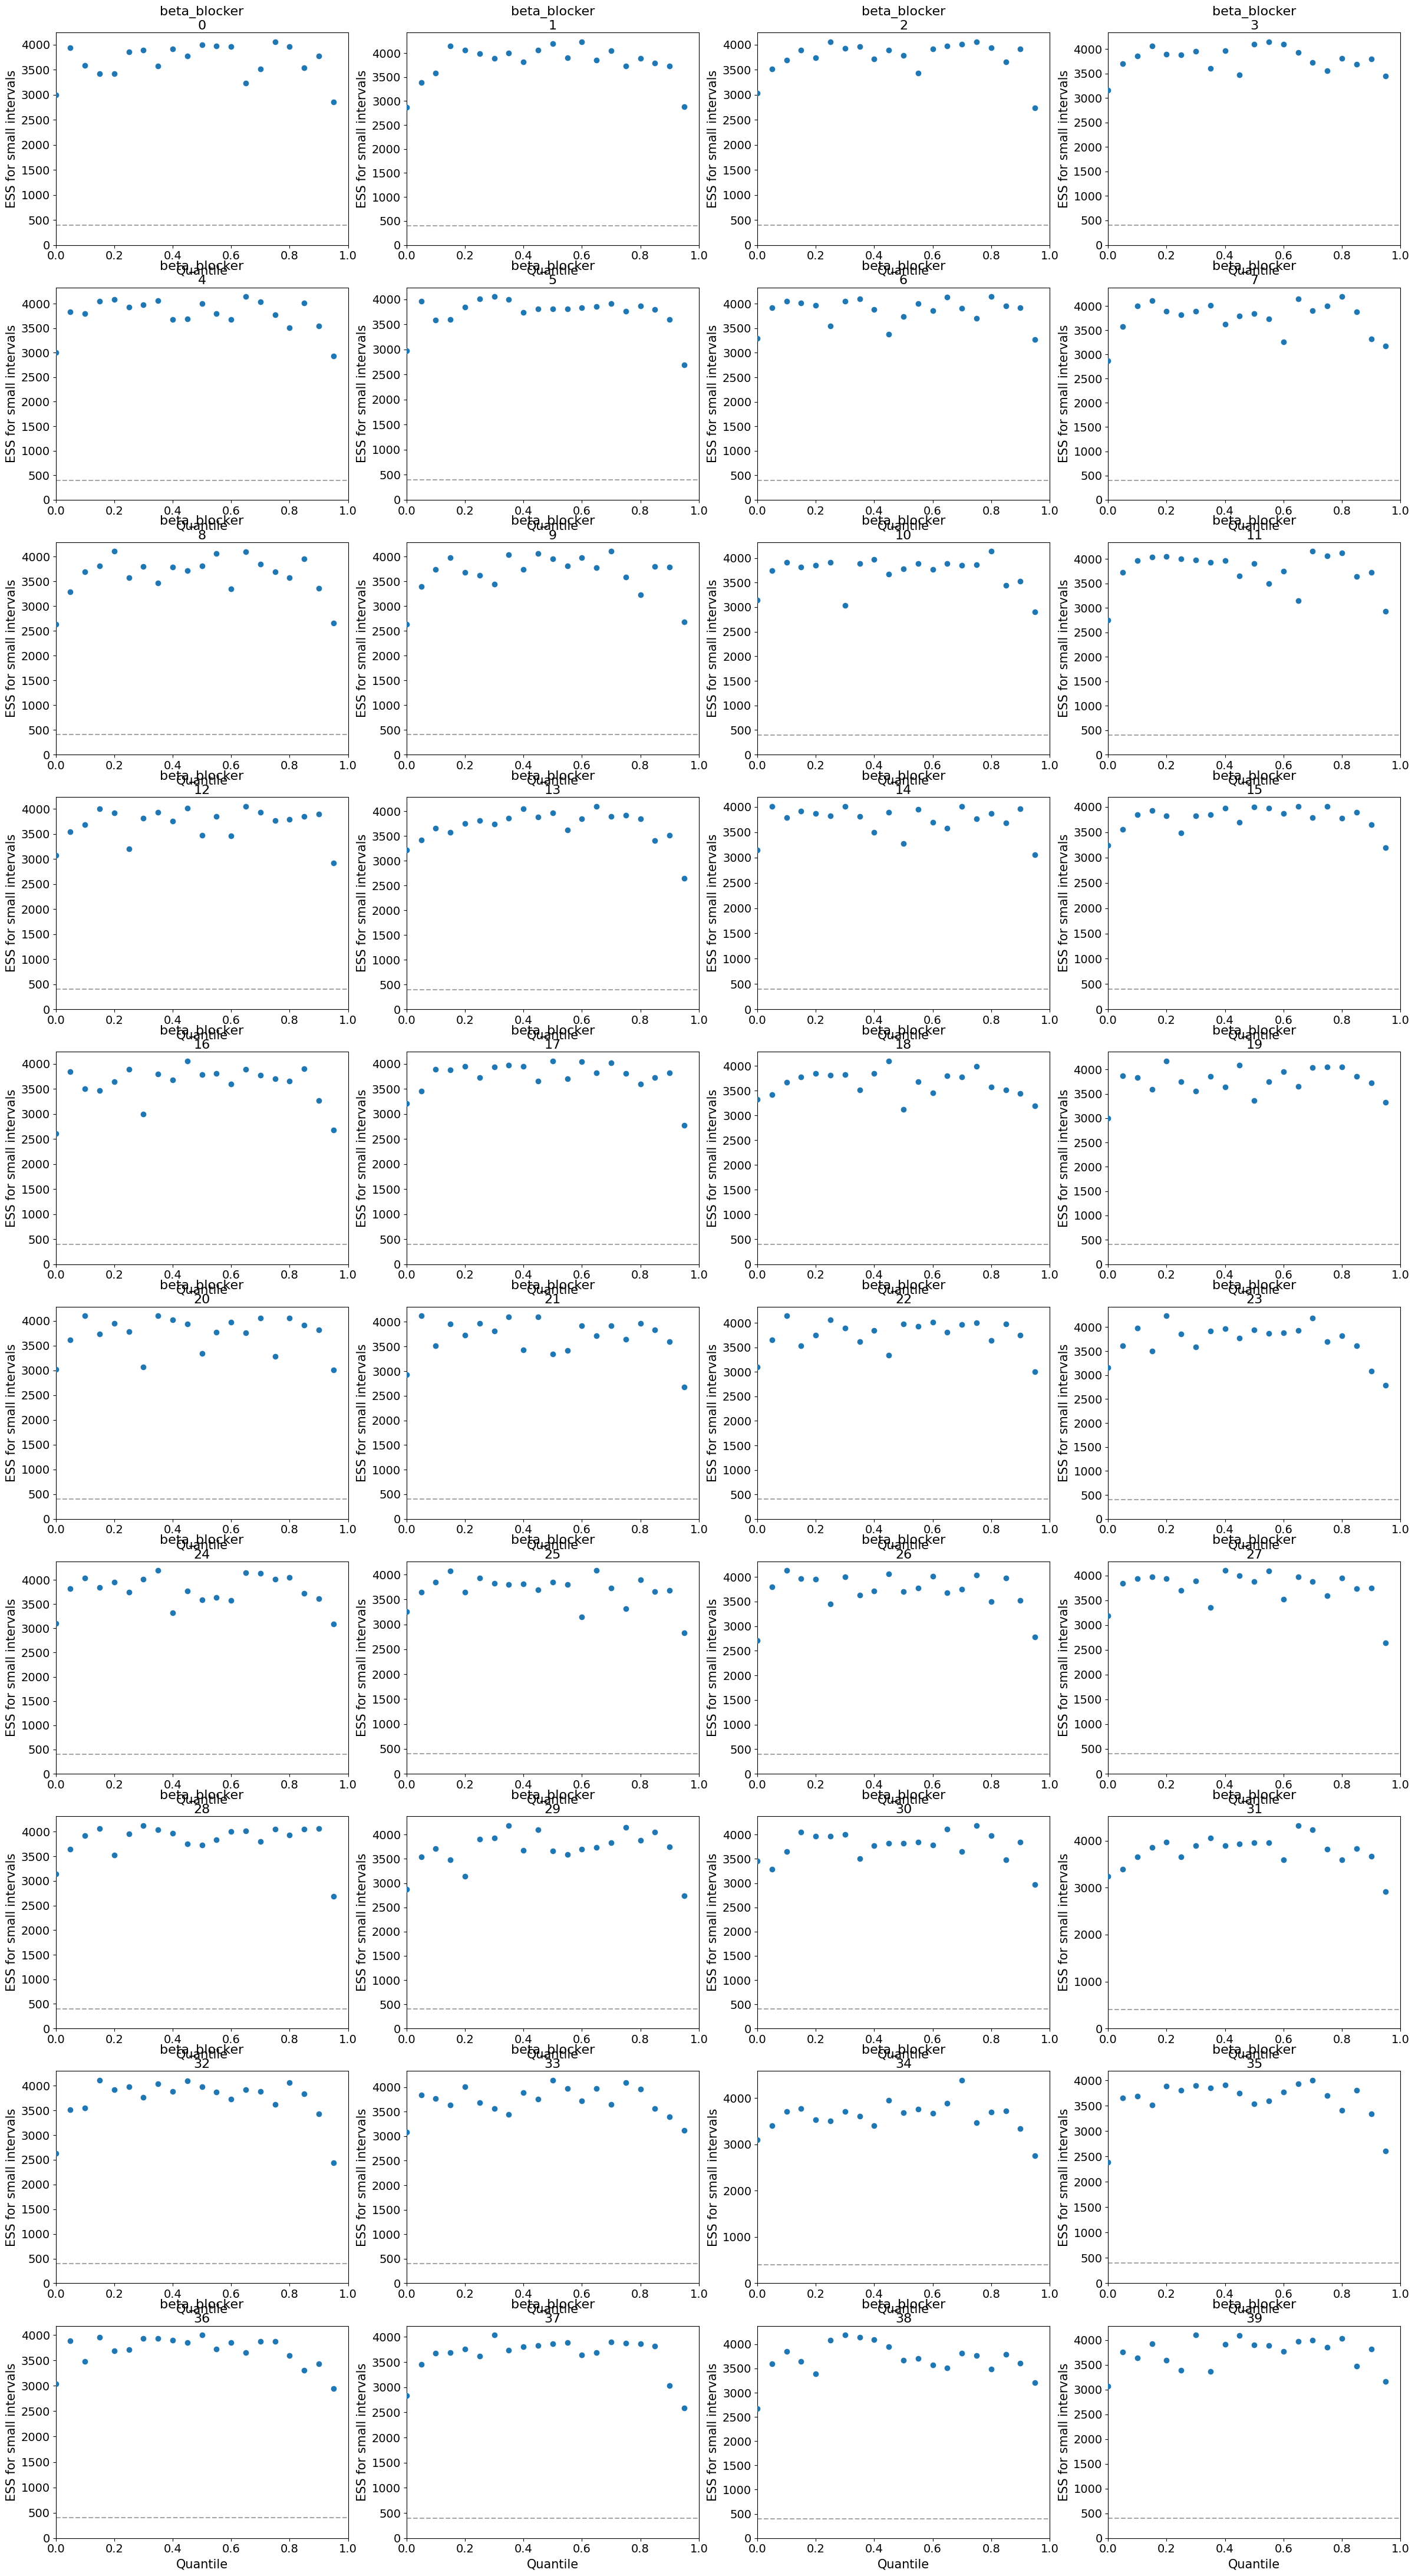

In [52]:
az.plot_ess(idata_strain.posterior.beta_blocker)

/Users/abhijitbrahme/Library/Caches/pypoetry/virtualenvs/matchup-identifier-NB4Vme2p-py3.9/lib/python3.9/site-packages/arviz/plots/plot_utils.py:271: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (696) in plot_ess, generating only 40 plots
  warnings.warn(


array([[<AxesSubplot: title={'center': 'beta_rusher\n0'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_rusher\n1'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_rusher\n2'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_rusher\n3'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
       [<AxesSubplot: title={'center': 'beta_rusher\n4'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_rusher\n5'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_rusher\n6'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_rusher\n7'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
       [<AxesSubplot: title={'center': 'beta_rusher\n8'}, xlabel='Quantile', ylabel='ESS for small int

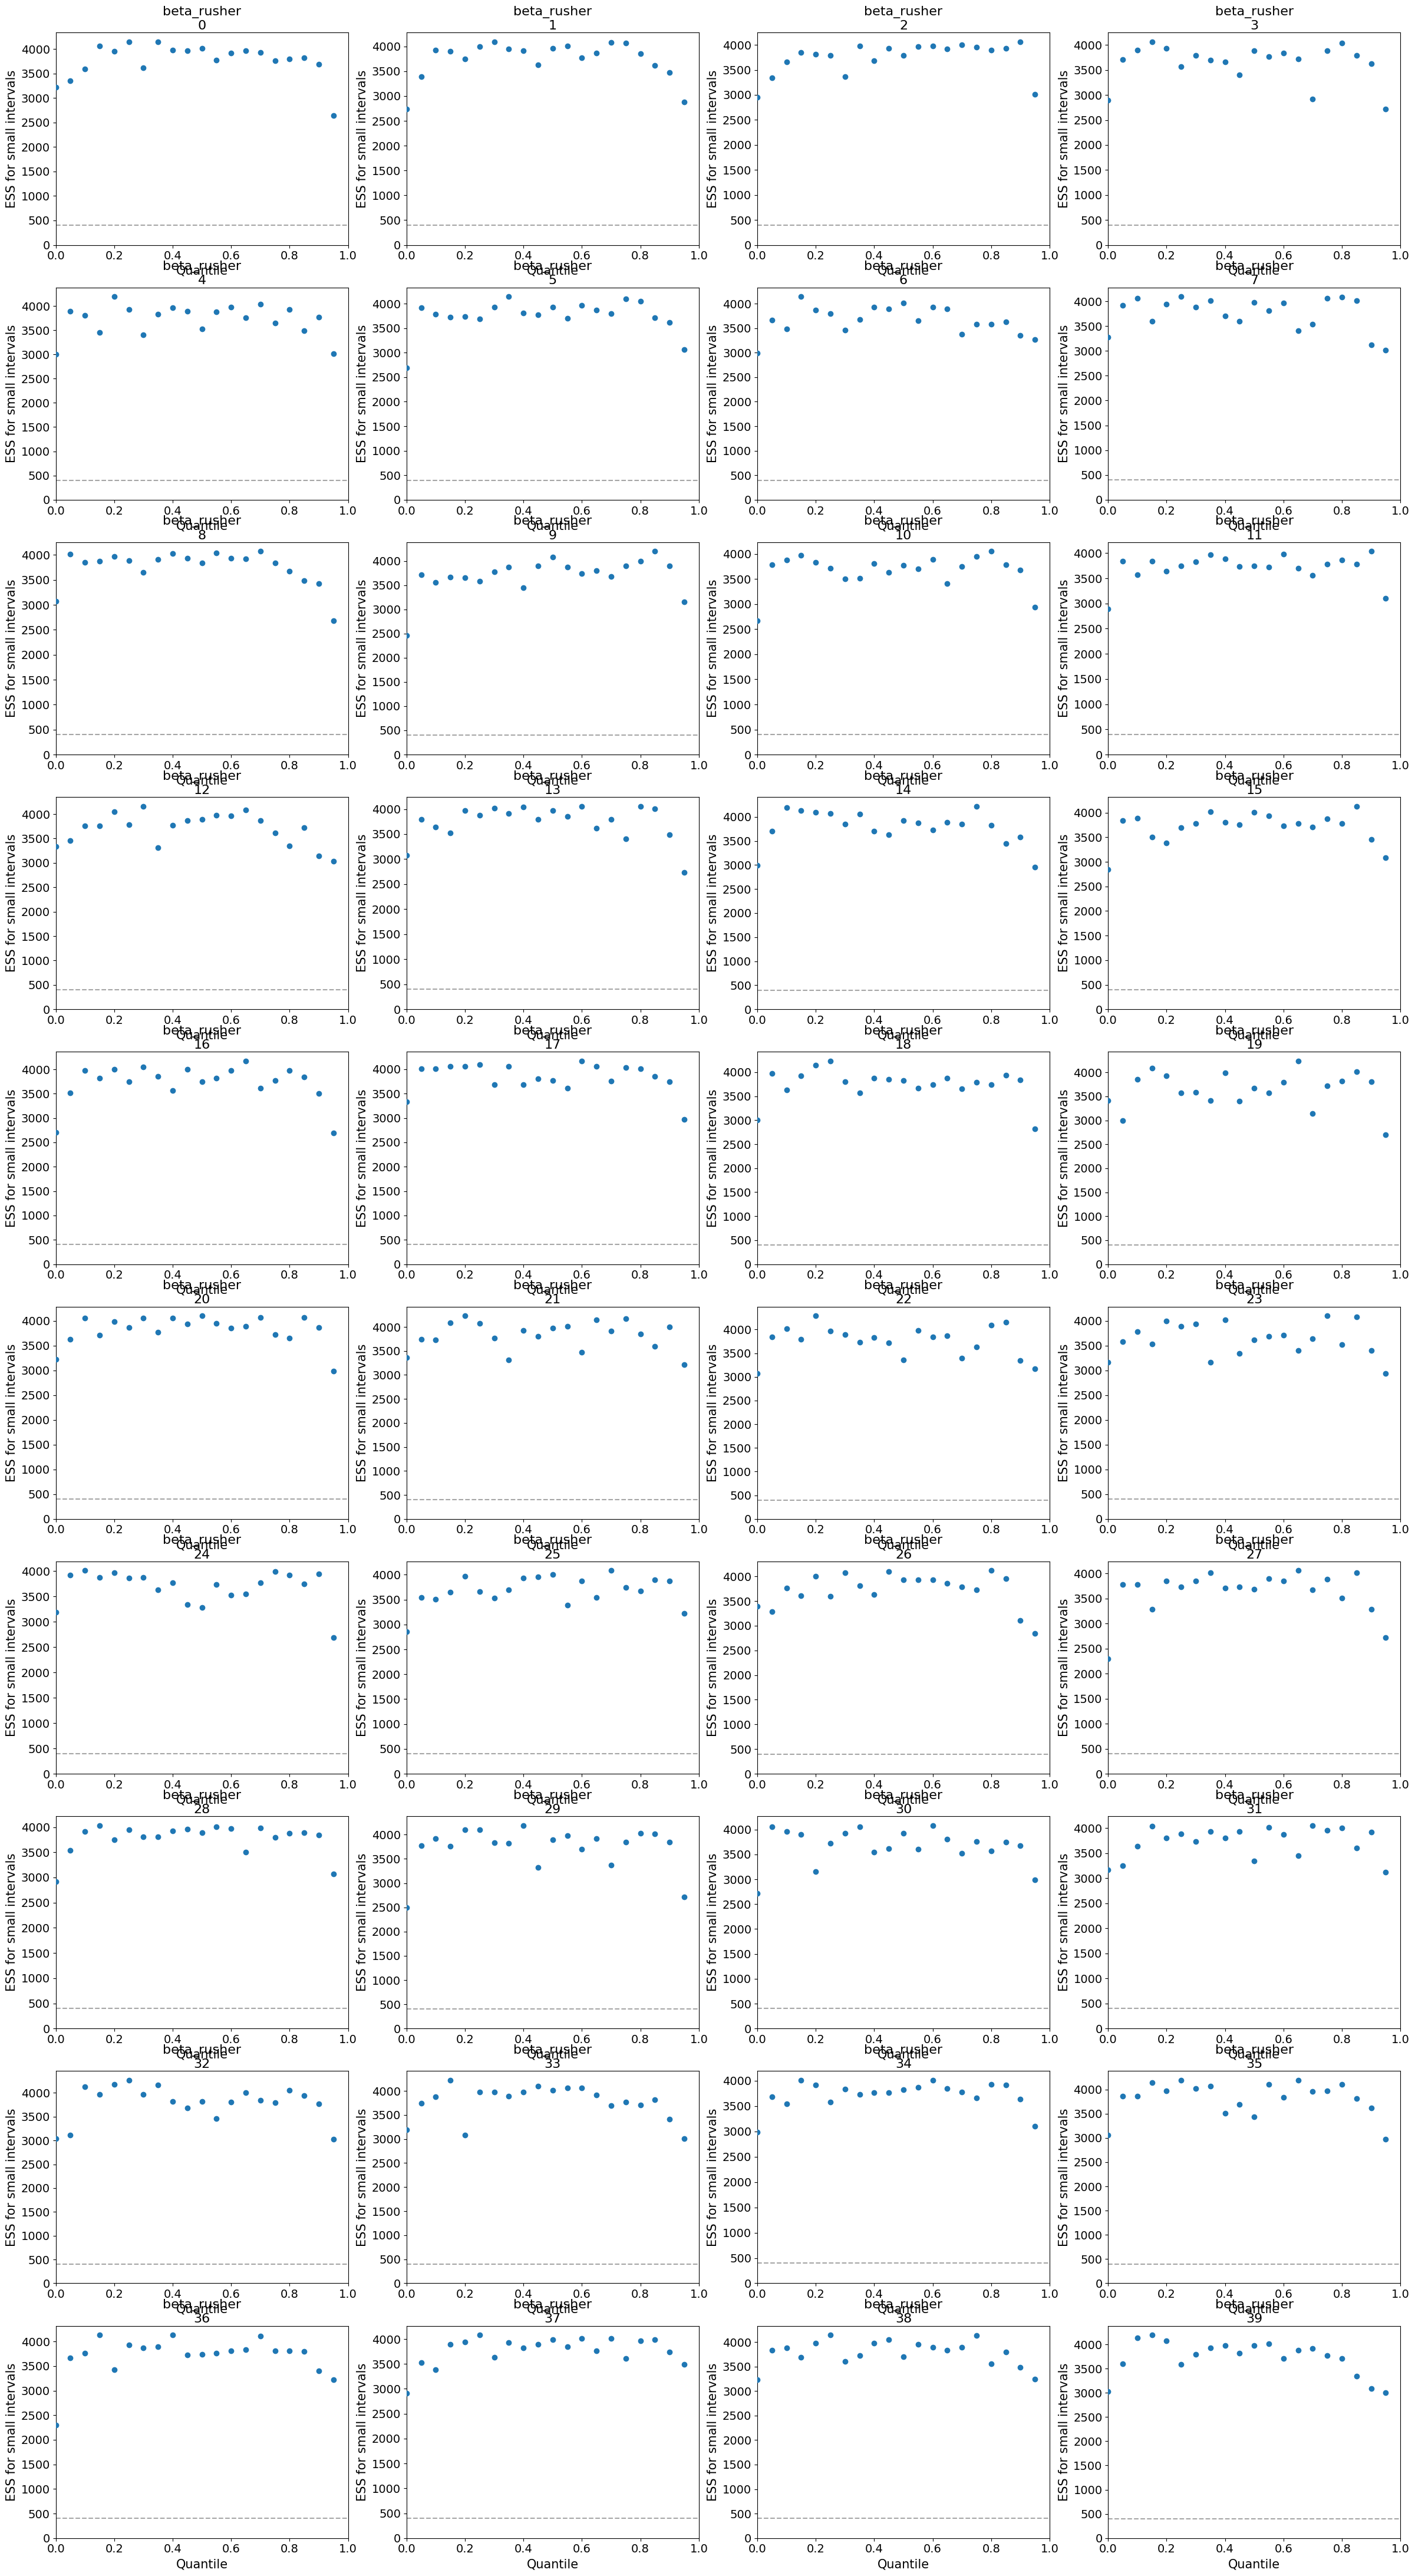

In [53]:
az.plot_ess(idata_strain.posterior.beta_rusher)

array([[<AxesSubplot: title={'center': 'beta_offense\n0'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_offense\n1'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_offense\n2'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_offense\n3'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
       [<AxesSubplot: title={'center': 'beta_offense\n4'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_offense\n5'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_offense\n6'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
        <AxesSubplot: title={'center': 'beta_offense\n7'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
       [<AxesSubplot: title={'center': 'beta_offense\n8'}, xlabel='Quantile', ylabel='ESS for 

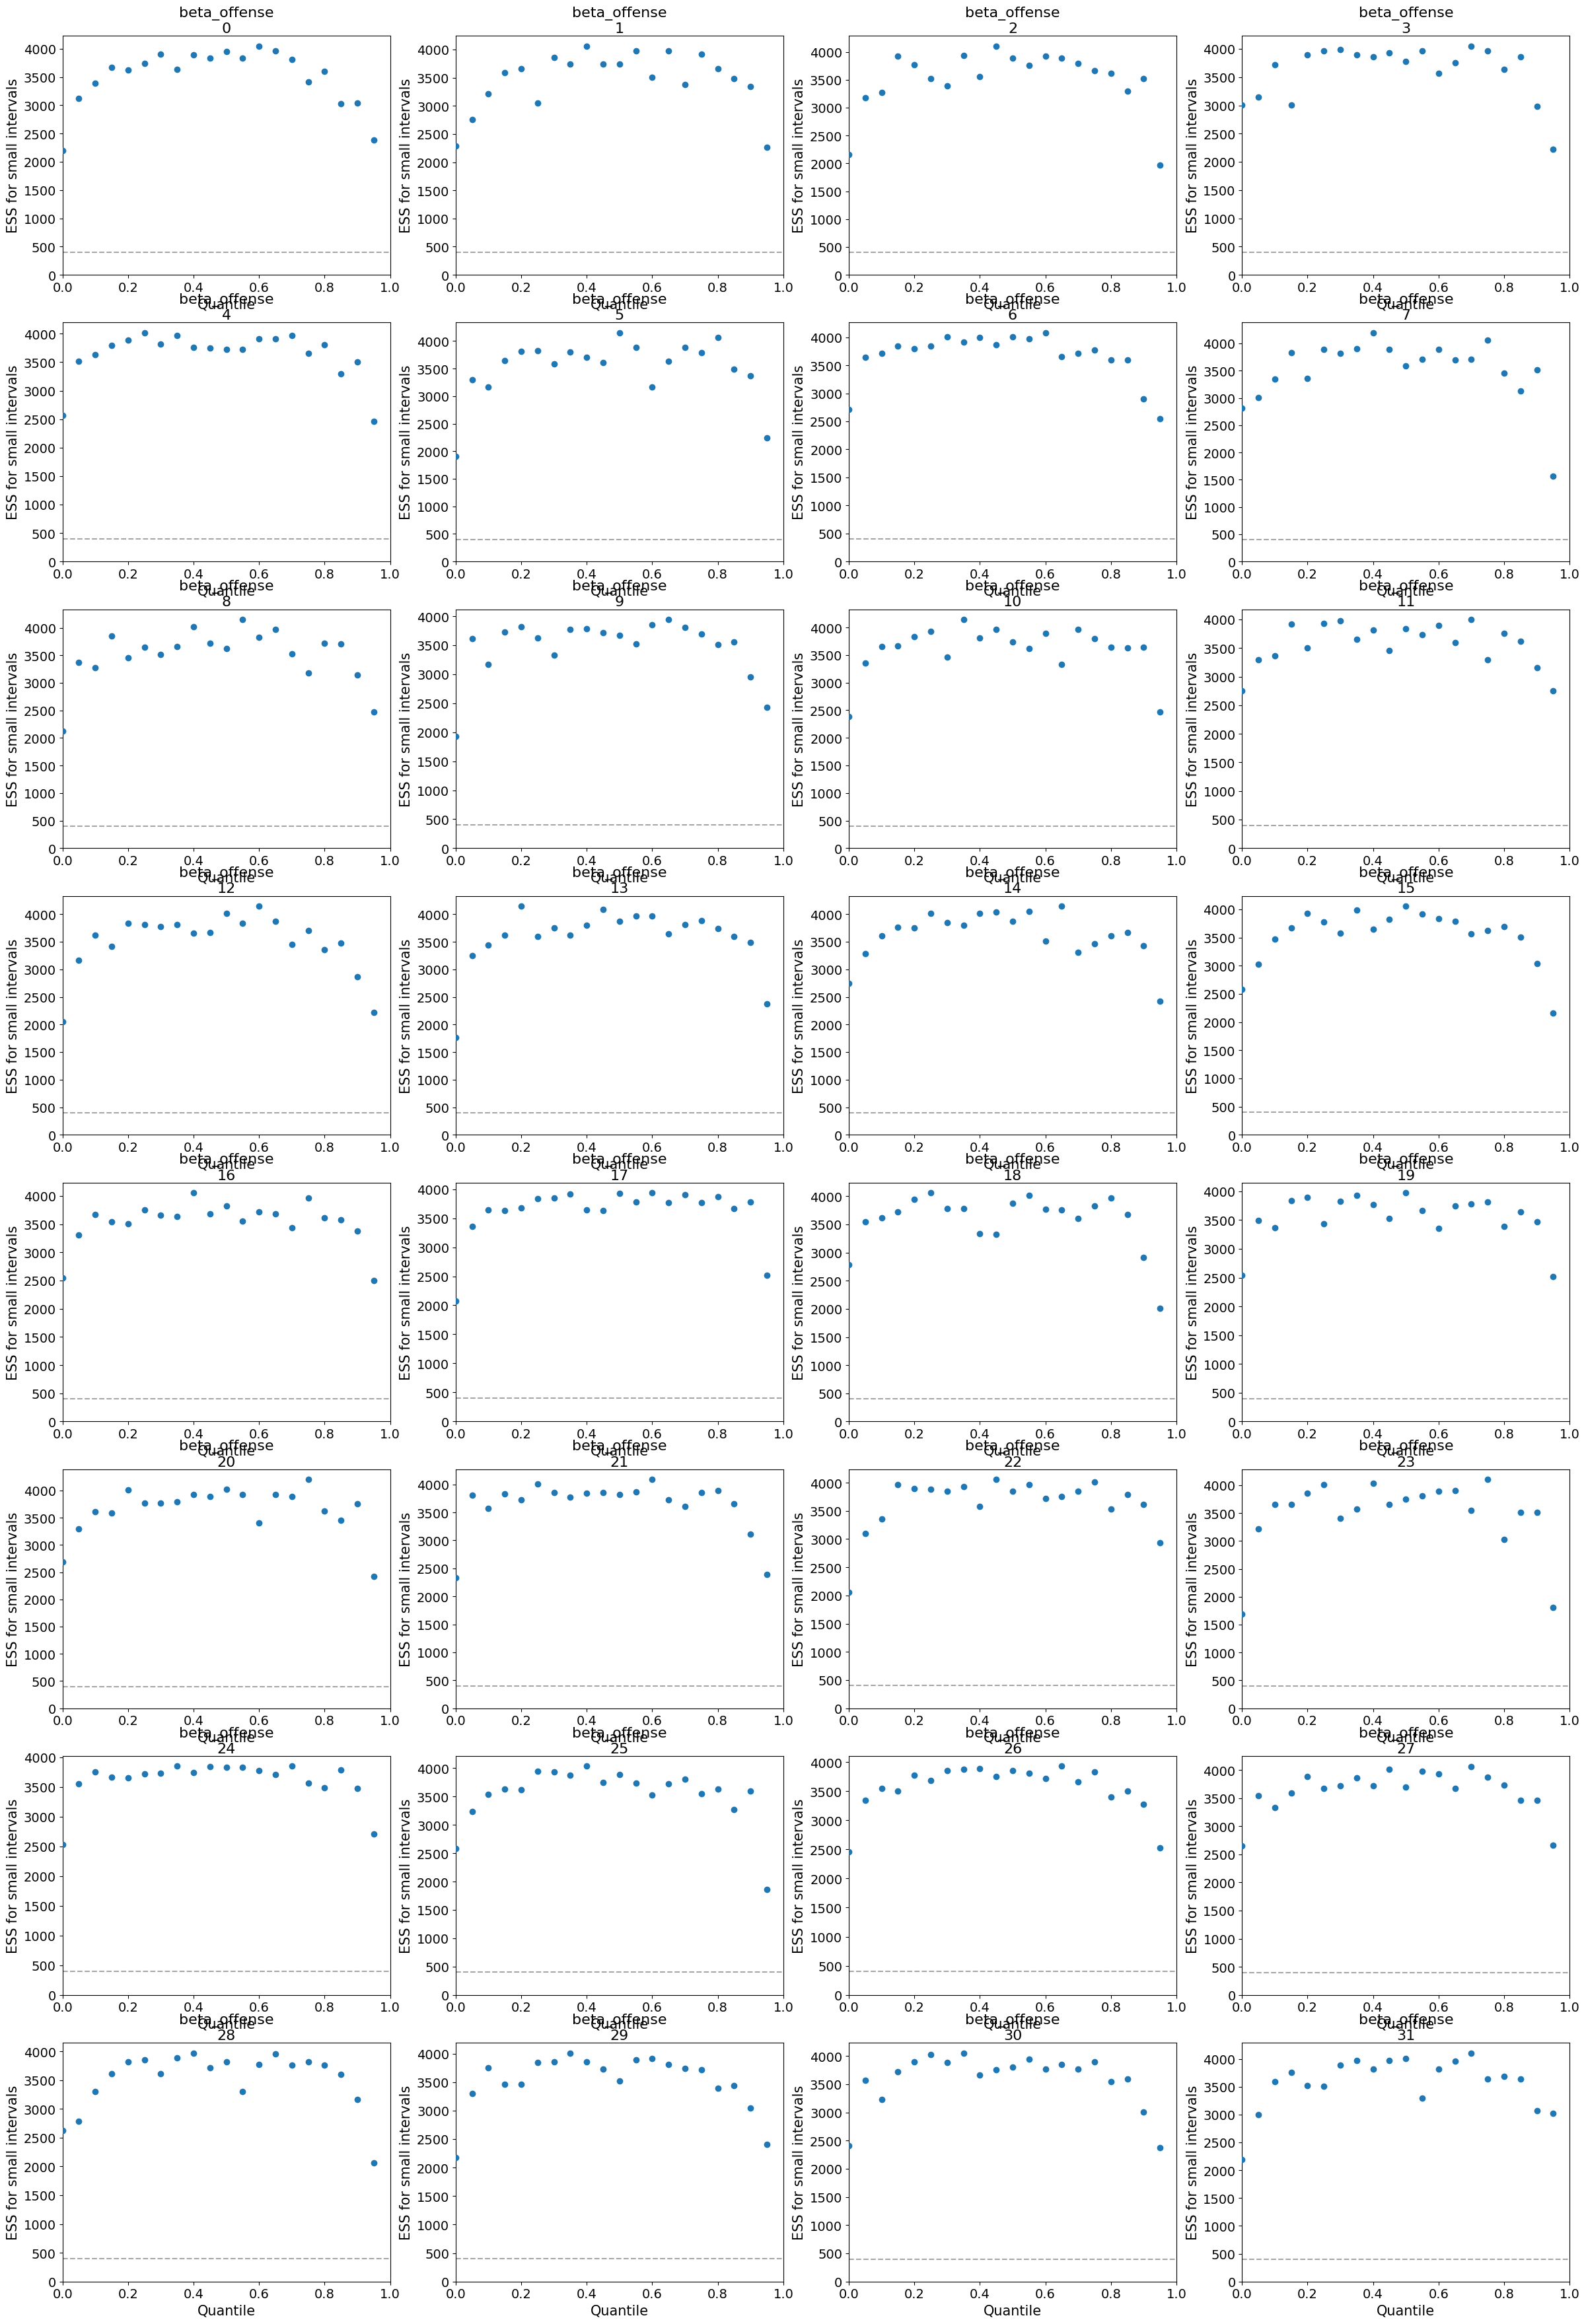

In [54]:
az.plot_ess(idata_strain.posterior.beta_offense)

<AxesSubplot: title={'center': 'sigma'}, xlabel='Quantile', ylabel='ESS for small intervals'>

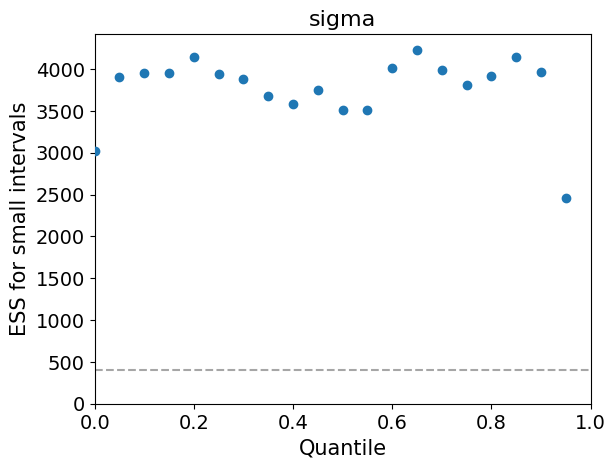

In [55]:
az.plot_ess(idata_strain.posterior.sigma)

<AxesSubplot: title={'center': 'sigma_rusher'}, xlabel='Quantile', ylabel='ESS for small intervals'>

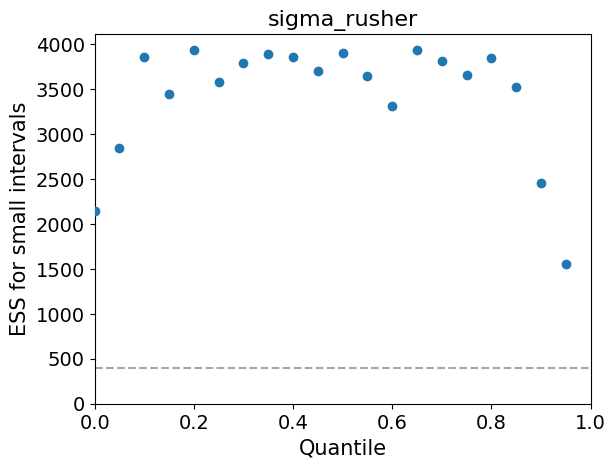

In [56]:
az.plot_ess(idata_strain.posterior.sigma_rusher)

<AxesSubplot: title={'center': 'sigma_blocker'}, xlabel='Quantile', ylabel='ESS for small intervals'>

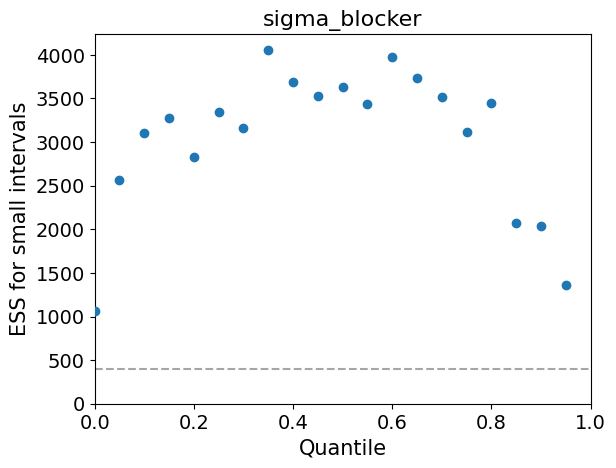

In [57]:
az.plot_ess(idata_strain.posterior.sigma_blocker)

In [58]:
az.summary(idata_strain.posterior.sigma)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.133,0.001,0.132,0.134,0.0,0.0,5741.0,2465.0,1.0


In [59]:
az.summary(idata_strain.posterior.sigma_rusher)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_rusher,0.029,0.001,0.027,0.032,0.0,0.0,941.0,1550.0,1.0


In [60]:
az.summary(idata_strain.posterior.sigma_blocker)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_blocker,0.021,0.002,0.017,0.024,0.0,0.0,498.0,1057.0,1.0


In [61]:
az.summary(idata_strain.posterior.sigma_offense)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_offense,0.017,0.003,0.012,0.022,0.0,0.0,1840.0,2316.0,1.0


In [62]:
az.summary(idata_strain.posterior.sigma_defense)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_defense,0.015,0.003,0.01,0.02,0.0,0.0,985.0,1668.0,1.0


In [63]:
az.summary(idata_strain.posterior.beta_blocker)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_blocker[0],-0.008,0.010,-0.029,0.010,0.0,0.0,2422.0,2855.0,1.0
beta_blocker[1],-0.021,0.011,-0.042,-0.000,0.0,0.0,2999.0,2866.0,1.0
beta_blocker[2],-0.013,0.012,-0.036,0.009,0.0,0.0,3323.0,2737.0,1.0
beta_blocker[3],-0.008,0.012,-0.030,0.013,0.0,0.0,3018.0,3158.0,1.0
beta_blocker[4],0.007,0.011,-0.013,0.029,0.0,0.0,3144.0,2931.0,1.0
...,...,...,...,...,...,...,...,...,...
beta_blocker[397],0.000,0.020,-0.035,0.039,0.0,0.0,5040.0,2858.0,1.0
beta_blocker[398],0.003,0.020,-0.032,0.044,0.0,0.0,6559.0,2742.0,1.0
beta_blocker[399],0.015,0.021,-0.024,0.054,0.0,0.0,5806.0,2393.0,1.0
beta_blocker[400],-0.010,0.020,-0.050,0.026,0.0,0.0,4972.0,2751.0,1.0


In [64]:
az.summary(idata_strain.posterior.beta_rusher)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_rusher[0],0.006,0.014,-0.021,0.030,0.0,0.000,2267.0,2636.0,1.0
beta_rusher[1],0.032,0.012,0.010,0.055,0.0,0.000,1808.0,2738.0,1.0
beta_rusher[2],-0.039,0.015,-0.068,-0.011,0.0,0.000,2569.0,2956.0,1.0
beta_rusher[3],-0.070,0.016,-0.100,-0.040,0.0,0.000,2817.0,2717.0,1.0
beta_rusher[4],-0.002,0.023,-0.044,0.041,0.0,0.000,4549.0,3007.0,1.0
...,...,...,...,...,...,...,...,...,...
beta_rusher[691],-0.000,0.030,-0.055,0.057,0.0,0.000,5522.0,3058.0,1.0
beta_rusher[692],0.001,0.029,-0.054,0.057,0.0,0.000,5851.0,3127.0,1.0
beta_rusher[693],-0.008,0.029,-0.060,0.045,0.0,0.000,5668.0,3032.0,1.0
beta_rusher[694],-0.001,0.029,-0.051,0.060,0.0,0.001,7065.0,2860.0,1.0


In [65]:
az.summary(idata_strain.posterior.beta_offense)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_offense[0],0.008,0.008,-0.007,0.023,0.0,0.0,1372.0,2194.0,1.0
beta_offense[1],0.012,0.008,-0.002,0.028,0.0,0.0,1440.0,2269.0,1.0
beta_offense[2],0.006,0.008,-0.010,0.020,0.0,0.0,1422.0,1971.0,1.0
beta_offense[3],-0.004,0.008,-0.020,0.010,0.0,0.0,1792.0,2227.0,1.0
beta_offense[4],-0.005,0.009,-0.021,0.012,0.0,0.0,1648.0,2459.0,1.0
beta_offense[5],-0.015,0.008,-0.029,0.001,0.0,0.0,1477.0,1902.0,1.0
beta_offense[6],0.006,0.008,-0.010,0.021,0.0,0.0,1664.0,2550.0,1.0
beta_offense[7],0.023,0.008,0.008,0.038,0.0,0.0,1135.0,1564.0,1.0
beta_offense[8],-0.029,0.008,-0.045,-0.015,0.0,0.0,1542.0,2127.0,1.0
beta_offense[9],0.003,0.008,-0.013,0.018,0.0,0.0,1366.0,1933.0,1.0


In [66]:
az.summary(idata_strain.posterior.beta_defense)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_defense[0],-0.020,0.008,-0.036,-0.004,0.0,0.0,1112.0,1829.0,1.0
beta_defense[1],-0.005,0.008,-0.020,0.010,0.0,0.0,1891.0,2432.0,1.0
beta_defense[2],0.010,0.008,-0.005,0.025,0.0,0.0,1699.0,2523.0,1.0
beta_defense[3],0.001,0.008,-0.014,0.017,0.0,0.0,1651.0,2342.0,1.0
beta_defense[4],-0.010,0.007,-0.023,0.004,0.0,0.0,1597.0,2360.0,1.0
beta_defense[5],-0.005,0.008,-0.020,0.010,0.0,0.0,1469.0,2031.0,1.0
beta_defense[6],-0.005,0.008,-0.020,0.010,0.0,0.0,1690.0,2483.0,1.0
beta_defense[7],0.006,0.008,-0.009,0.021,0.0,0.0,1679.0,2293.0,1.0
beta_defense[8],0.008,0.008,-0.008,0.024,0.0,0.0,1597.0,2478.0,1.0
beta_defense[9],0.009,0.009,-0.008,0.024,0.0,0.0,1496.0,2103.0,1.0


In [67]:
az.summary(idata_strain.posterior.intercept)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,0.266,0.014,0.24,0.293,0.0,0.0,1044.0,1901.0,1.0


In [68]:
az.summary(idata_strain.posterior.beta_covariates)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_covariates[0],0.003,0.000,0.002,0.003,0.000,0.000,6158.0,3119.0,1.00
beta_covariates[1],-0.043,0.001,-0.045,-0.041,0.000,0.000,4042.0,3172.0,1.00
beta_covariates[2],0.008,0.012,-0.013,0.030,0.000,0.000,1021.0,1764.0,1.00
beta_covariates[3],0.034,0.011,0.013,0.056,0.000,0.000,1007.0,1683.0,1.00
beta_covariates[4],0.064,0.011,0.042,0.085,0.000,0.000,1029.0,1773.0,1.00
beta_covariates[5],0.050,0.012,0.028,0.073,0.000,0.000,1072.0,1879.0,1.00
beta_covariates[6],0.000,0.005,-0.008,0.009,0.000,0.000,1024.0,1629.0,1.00
beta_covariates[7],-0.006,0.004,-0.015,0.002,0.000,0.000,1014.0,1884.0,1.00
beta_covariates[8],-0.010,0.005,-0.021,0.000,0.000,0.000,1449.0,2193.0,1.00
beta_covariates[9],-0.067,0.004,-0.075,-0.058,0.000,0.000,745.0,1230.0,1.01


In [69]:
rusher_summary_play = az.summary(idata_strain.posterior.beta_rusher).reset_index()

In [70]:
rusher_summary_play["nflId"] = rusher_summary_play["index"].apply(lambda x: rusher_dict[int(re.search(pattern, x).group(1))])

In [71]:
rusher_summary_play = rusher_summary_play.merge(player_data[["nflId","displayName","officialPosition"]]).merge(snap_count)

In [73]:
rusher_summary_play[rusher_summary_play["snap_count"] > 100].groupby("officialPosition").apply(lambda x: x.sort_values(by = "mean", ascending = False).head(5))[["mean","displayName","officialPosition"]]


mean          displayName officialPosition
officialPosition                                                 
DE               127  0.067     Jadeveon Clowney               DE
                 246  0.048           Dean Lowry               DE
                 214  0.034        Kingsley Keke               DE
                 206  0.031           Zach Allen               DE
                 204  0.027            J.J. Watt               DE
DT               182  0.043      Cameron Heyward               DT
                 13   0.043    Christian Barmore               DT
                 129  0.038       Malik McDowell               DT
                 73   0.034     Leonard Williams               DT
                 1    0.032        Grady Jarrett               DT
NT               28   0.042       Davon Godchaux               NT
                 293  0.041  Christian Covington               NT
                 111  0.011     Quinnen Williams               NT
                 326  0.009          D.J. Reader               NT
                 201  0.005          Greg Gaines               NT
OLB              77   0.046        Azeez Ojulari              OLB
                 55   0.033        Leonard Floyd              OLB
                 12   0.031            Josh Uche              OLB
                 123  0.031       Justin Houston              OLB
                 158  0.025            T.J. Watt              OLB

In [74]:
blocker_summary_play = az.summary(idata_strain.posterior.beta_blocker).reset_index()

In [75]:

blocker_map_play = {val: key for val, key in enumerate(pd.factorize(feature_data["assigned_blocker_id"])[1])}

In [77]:
blocker_summary_play["nflId"] = blocker_summary_play["index"].apply(lambda x: blocker_map_play[int(re.search(pattern, x).group(1))])

In [78]:
blocker_summary_play = blocker_summary_play.merge(player_data[["nflId","displayName","officialPosition"]]).merge(snap_count)

In [86]:
blocker_summary_play[blocker_summary_play["snap_count"] > 80].groupby("officialPosition").apply(lambda x: x.sort_values(by = "mean", ascending = True).head(10))[["displayName","officialPosition","mean","hdi_3%","hdi_97%"]].to_csv(index = False)

'displayName,officialPosition,mean,hdi_3%,hdi_97%\nMatt Skura,C,-0.036,-0.061,-0.011\nBen Jones,C,-0.023,-0.043,-0.004\nAlex Mack,C,-0.021,-0.044,0.002\nTed Karras,C,-0.02,-0.044,0.003\nChase Roullier,C,-0.015,-0.035,0.005\nRodney Hudson,C,-0.013,-0.036,0.011\nJ.C. Tretter,C,-0.008,-0.032,0.012\nLloyd Cushenberry,C,-0.008,-0.028,0.011\nMax Garcia,C,-0.008,-0.03,0.015\nCorey Linsley,C,-0.008,-0.029,0.013\nAndrew Norwell,G,-0.036,-0.063,-0.01\nZack Martin,G,-0.035,-0.057,-0.015\nWyatt Teller,G,-0.027,-0.048,-0.006\nTrey Smith,G,-0.026,-0.049,-0.003\nMax Scharping,G,-0.023,-0.044,-0.003\nJonah Jackson,G,-0.021,-0.046,0.001\nJosh Jones,G,-0.019,-0.04,0.002\nGreg Van Roten,G,-0.016,-0.037,0.005\nKyle Fuller,G,-0.016,-0.037,0.006\nLucas Patrick,G,-0.016,-0.037,0.008\nEric Fisher,T,-0.024,-0.051,0.002\nAndrew Thomas,T,-0.024,-0.049,-0.0\nMatt Peart,T,-0.023,-0.052,0.003\nRiley Reiff,T,-0.022,-0.046,0.001\nTaylor Moton,T,-0.021,-0.042,-0.0\nYosuah Nijman,T,-0.017,-0.043,0.008\nOlisaemeka Udoh,

In [80]:
blocker_summary_play

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,nflId,displayName,officialPosition,snap_count
0,beta_blocker[0],-0.008,0.010,-0.029,0.010,0.0,0.0,2422.0,2855.0,1.0,42377,Donovan Smith,T,306
1,beta_blocker[1],-0.021,0.011,-0.042,-0.000,0.0,0.0,2999.0,2866.0,1.0,44876,Taylor Moton,T,294
2,beta_blocker[2],-0.013,0.012,-0.036,0.009,0.0,0.0,3323.0,2737.0,1.0,38642,Bobby Massie,T,292
3,beta_blocker[3],-0.008,0.012,-0.030,0.013,0.0,0.0,3018.0,3158.0,1.0,41310,Gabe Jackson,G,233
4,beta_blocker[4],0.007,0.011,-0.013,0.029,0.0,0.0,3144.0,2931.0,1.0,42371,Laken Tomlinson,G,219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,beta_blocker[397],0.000,0.020,-0.035,0.039,0.0,0.0,5040.0,2858.0,1.0,48011,Tommy Sweeney,TE,8
398,beta_blocker[398],0.003,0.020,-0.032,0.044,0.0,0.0,6559.0,2742.0,1.0,52859,Rodney Smith,RB,6
399,beta_blocker[399],0.015,0.021,-0.024,0.054,0.0,0.0,5806.0,2393.0,1.0,42416,Tevin Coleman,RB,6
400,beta_blocker[400],-0.010,0.020,-0.050,0.026,0.0,0.0,4972.0,2751.0,1.0,42500,C.J. Uzomah,TE,18


In [225]:
feature_data = pd.read_csv("src/strain_design_data.csv")
feature_data["grouped_pass_rusher_position"] = feature_data["officialPosition"].apply(lambda x: "S" if x in ["SS","FS", "CB"] else x)
feature_data["grouped_pass_rusher_position"] = feature_data["grouped_pass_rusher_position"].apply(lambda x: "I" if x in ["MLB", "ILB", "LB"] else x)

plays = pd.read_csv("src/data/plays.csv")
feature_data = feature_data.merge(plays[["gameId","playId","possessionTeam","defensiveTeam", "down", "yardsToGo"]], on = ["gameId","playId"])

feature_data = feature_data[
    ~feature_data["grouped_pass_rusher_position"].isin(["G", "RB"])
]
feature_data["assignment_dict"] = feature_data["assignment_dict"].apply(
    lambda x: ast.literal_eval(x)
)
target = feature_data["strain_rate"]

all_blockers = set().union(*(d.keys() for d in feature_data["assignment_dict"]))

n_blockers = len(all_blockers)
n_rushers = len(feature_data["nflId_pr"].unique())
n_offense = len(feature_data["possessionTeam"].unique())
n_defense = len(feature_data["defensiveTeam"].unique())

blocker_map = {key: val for val, key in enumerate(all_blockers)}

N = feature_data.shape[0]
print("making design matrix for blockers")
blocker_design_matrix = np.zeros((N, n_blockers))
i = 0
for _, row in feature_data.iterrows():
    assignment_map = row["assignment_dict"]
    blocker_design_matrix[
        i, [blocker_map[nfl_id] for nfl_id in assignment_map.keys()]
    ] = list(assignment_map.values())
    i += 1
print("finished making design matrix for blockers")

making design matrix for blockers
finished making design matrix for blockers


In [232]:
weighted_blocker_difficulty =  blocker_design_matrix * rusher_summary[["mean","nflId"]].merge(feature_data, left_on = "nflId", right_on = "nflId_pr")[["mean"]].values 

In [233]:
masked_blocker_difficulty = np.ma.masked_array(weighted_blocker_difficulty, (weighted_blocker_difficulty == 0))

In [236]:
blocking_assignment_difficulty = masked_blocker_difficulty.mean(axis = 0).data

In [ ]:
blocker_summary

### Calculate Statistics for Drag Based Model

In [96]:
idata_drag = az.from_netcdf("src/pymc_posterior_sample_qb.nc")

In [148]:
blocker_summary_drag = az.summary(idata_drag.posterior.beta_blocker).reset_index()

In [99]:
blocker_summary_drag

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,beta_blocker[0],0.316,0.308,-0.240,0.911,0.006,0.005,2901.0,1439.0,1.0
1,beta_blocker[1],-3.347,1.329,-5.793,-0.834,0.021,0.016,4073.0,1108.0,1.0
2,beta_blocker[2],0.446,0.050,0.356,0.544,0.001,0.001,3689.0,1365.0,1.0
3,beta_blocker[3],-0.189,0.029,-0.241,-0.133,0.001,0.000,2367.0,1442.0,1.0
4,beta_blocker[4],1.776,3.277,-4.654,7.639,0.053,0.066,3802.0,1371.0,1.0
...,...,...,...,...,...,...,...,...,...,...
529,beta_blocker[529],1.445,0.308,0.836,1.987,0.006,0.004,3088.0,1581.0,1.0
530,beta_blocker[530],-1.702,3.949,-9.285,5.372,0.065,0.093,3660.0,1395.0,1.0
531,beta_blocker[531],0.523,0.030,0.467,0.575,0.001,0.000,3290.0,1577.0,1.0
532,beta_blocker[532],-0.620,0.934,-2.298,1.145,0.014,0.023,4388.0,1364.0,1.0


In [119]:
import pickle
feature_data = pd.read_csv("src/strain_design_data.csv")

In [102]:
rusher_inverse_map = {val: index for index,val in pickle.load(open("src/rusher_encoding.pkl","rb")).items() }
blocker_inverse_map = {val: index for index,val in pickle.load(open("src/blocker_encoding.pkl","rb")).items() }

In [149]:
blocker_map = pickle.load(open("src/blocker_encoding.pkl","rb"))

In [150]:
blocker_summary_drag["nflId"] = blocker_summary_drag["index"].apply(lambda x: blocker_map[int(re.search(pattern, x).group(1))])

In [151]:
blocker_summary_drag = blocker_summary_drag.merge(player_data[["nflId","displayName","officialPosition"]]).merge(snap_count)

In [111]:
design_matrix = pd.read_csv("src/blocker_rusher_design_matrix.csv").to_numpy()[:, 1:]

In [117]:
drag_coefficient = (design_matrix * blocker_summary_drag["mean"].values).sum(axis = 1)

In [123]:
drag_force = (feature_data[["strain_rate"]].values ** 2) * .5 * (design_matrix * blocker_summary_drag["mean"].values) 

In [137]:
masked_drag_force = np.ma.masked_array(drag_force, (drag_force == 0))

In [140]:
average_drag_force = masked_drag_force.mean(axis = 0).data

In [152]:
blocker_summary_drag["average_drag_force"] = average_drag_force

In [156]:
blocker_summary_drag[blocker_summary_drag.snap_count >= 80].groupby("officialPosition").apply(lambda x: x.sort_values("average_drag_force", ascending = False).head(10))


index   mean     sd  hdi_3%  hdi_97%  \
officialPosition                                                         
C                241  beta_blocker[241]  0.812  0.010   0.794    0.829   
                 428  beta_blocker[428]  1.299  0.018   1.263    1.332   
                 131  beta_blocker[131]  2.715  0.072   2.582    2.850   
                 181  beta_blocker[181]  1.141  0.029   1.091    1.197   
                 63    beta_blocker[63]  0.613  0.010   0.593    0.631   
                 121  beta_blocker[121]  0.642  0.021   0.602    0.679   
                 193  beta_blocker[193]  0.657  0.132   0.420    0.908   
                 529  beta_blocker[529]  1.445  0.308   0.836    1.987   
                 44    beta_blocker[44]  0.410  0.105   0.215    0.609   
                 531  beta_blocker[531]  0.523  0.030   0.467    0.575   
G                154  beta_blocker[154]  4.358  0.356   3.677    5.014   
                 162  beta_blocker[162]  1.019  0.012   0.995    1.041   
                 380  beta_blocker[380]  0.975  0.028   0.925    1.030   
                 117  beta_blocker[117]  0.896  0.014   0.870    0.923   
                 386  beta_blocker[386]  0.990  0.098   0.805    1.175   
                 95    beta_blocker[95]  1.247  0.028   1.198    1.299   
                 185  beta_blocker[185]  0.834  0.029   0.780    0.891   
                 127  beta_blocker[127]  1.129  0.015   1.102    1.159   
                 179  beta_blocker[179]  0.824  0.015   0.797    0.852   
                 238  beta_blocker[238]  0.920  0.018   0.885    0.952   
T                350  beta_blocker[350]  4.561  0.165   4.260    4.886   
                 94    beta_blocker[94]  0.999  0.028   0.947    1.052   
                 73    beta_blocker[73]  1.566  0.067   1.446    1.690   
                 412  beta_blocker[412]  1.071  0.032   1.014    1.132   
                 311  beta_blocker[311]  1.054  0.013   1.030    1.078   
                 161  beta_blocker[161]  3.625  0.365   2.969    4.345   
                 270  beta_blocker[270]  0.843  0.025   0.796    0.888   
                 239  beta_blocker[239]  1.008  0.013   0.983    1.034   
                 149  beta_blocker[149]  1.019  0.015   0.992    1.049   
                 369  beta_blocker[369]  1.702  0.083   1.551    1.856   

                      mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat  nflId  \
officialPosition                                                             
C                241      0.000    0.000    4389.0    1288.0   1.00  46089   
                 428      0.000    0.000    2150.0    1570.0   1.00  42476   
                 131      0.002    0.001    1850.0    1718.0   1.00  41436   
                 181      0.001    0.000    3133.0    1364.0   1.00  47831   
                 63       0.000    0.000    4546.0    1612.0   1.00  43307   
                 121      0.000    0.000    2705.0    1333.0   1.00  43433   
                 193      0.003    0.002    2739.0    1612.0   1.00  47861   
                 529      0.006    0.004    3088.0    1581.0   1.00  42954   
                 44       0.002    0.001    2787.0    1632.0   1.00  53516   
                 531      0.001    0.000    3290.0    1577.0   1.00  45012   
G                154      0.008    0.006    2023.0    1480.0   1.00  35472   
                 162      0.000    0.000    4116.0    1496.0   1.00  47797   
                 380      0.000    0.000    3259.0    1587.0   1.00  48485   
                 117      0.000    0.000    4544.0    1351.0   1.00  53655   
                 386      0.002    0.002    2087.0    1007.0   1.00  42356   
                 95       0.000    0.000    3301.0    1363.0   1.00  41310   
                 185      0.001    0.000    1932.0    1720.0   1.00  47838   
                 127      0.000    0.000    3592.0    1565.0   1.00  43453   
                 179      0.000    0.000    2689.0    1587.0   1.00  47824   
                 238      0

In [157]:
feature_data["drag_coefficient"] = drag_coefficient

In [180]:
feature_data["drag"] =  feature_data["drag_coefficient"] * .5 * (feature_data["strain_rate"] ** 2)

In [181]:
rusher_drag_coefficients = feature_data.groupby("nflId_pr")["drag"].mean().reset_index().merge(player_data[["nflId","displayName","officialPosition"]], left_on = "nflId_pr", right_on = "nflId").merge(snap_count)

In [183]:
rusher_drag_coefficients[rusher_drag_coefficients.snap_count >= 100 ].groupby("officialPosition").apply(lambda x: x.sort_values("drag",ascending=False).head(5))

nflId_pr      drag  nflId          displayName  \
officialPosition                                                       
DE               190     43358  0.073656  43358      Yannick Ngakoue   
                 19      37084  0.060643  37084            J.J. Watt   
                 425     47799  0.059935  47799          Brian Burns   
                 252     44838  0.042505  44838   Takkarist McKinley   
                 79      41227  0.040667  41227     Jadeveon Clowney   
DT               139     42443  0.057349  42443      Angelo Blackson   
                 319     46082  0.044182  46082          Daron Payne   
                 376     46249  0.017764  46249   Folorunso Fatukasi   
                 197     43378  0.016139  43378       Javon Hargrave   
                 241     44815  0.015006  44815       Solomon Thomas   
NT               171     43316  0.011801  43316          Kenny Clark   
                 151     42559  0.011363  42559  Christian Covington   
                 179     43332  0.003837  43332       Austin Johnson   
                 12      35485  0.002218  35485        Linval Joseph   
                 417     47786  0.001834  47786     Quinnen Williams   
OLB              165     43298  0.044351  43298        Leonard Floyd   
                 18      37075  0.043650  37075           Von Miller   
                 485     48089  0.037946  48089           Malik Reed   
                 106     41915  0.037516  41915      Shaquil Barrett   
                 250     44834  0.036799  44834       Charles Harris   

                     officialPosition  snap_count  
officialPosition                                   
DE               190               DE         198  
                 19                DE         188  
                 425               DE         202  
                 252               DE         120  
                 79                DE         172  
DT               139               DT         112  
                 319               DT         233  
                 376               DT         121  
                 197               DT         172  
                 241               DT         127  
NT               171               NT         238  
                 151               NT         124  
                 179               NT         130  
                 12                NT         117  
                 417               NT         152  
OLB              165              OLB         200  
                 18               OLB         160  
                 485              OLB         198  
                 106              OLB         222  
                 250              OLB         145

In [170]:
rusher_summary_drag = az.summary(idata_drag.posterior.beta_rusher).reset_index()

In [171]:
rusher_map = pickle.load(open("src/rusher_encoding.pkl","rb"))
rusher_summary_drag["nflId"] = rusher_summary_drag["index"].apply(lambda x: rusher_map[int(re.search(pattern, x).group(1))])

In [174]:
rusher_summary_drag[["mean","nflId"]].merge(rusher_drag_coefficients)[["mean","drag_coefficient","displayName","officialPosition", "snap_count"]].to_csv("src/rusher_drag_values.csv",index = False)

In [191]:
feature_data["officialPosition"].unique()

array(['DE', 'SS', 'FS', 'NT', 'DT', 'OLB', 'CB', 'MLB', 'ILB', 'G', 'RB',
       'LB'], dtype=object)

In [193]:
plays_data.columns.values

array(['gameId', 'playId', 'nflId', 'pff_role', 'pff_positionLinedUp',
       'pff_hit', 'pff_hurry', 'pff_sack', 'pff_beatenByDefender',
       'pff_hitAllowed', 'pff_hurryAllowed', 'pff_sackAllowed',
       'pff_nflIdBlockedPlayer', 'pff_blockType', 'pff_backFieldBlock'],
      dtype=object)